# End to End Deep Learning Project Using Simple RNN

In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import datetime

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing import sequence
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Input, SimpleRNN, GRU, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, TensorBoard
from sklearn.model_selection import train_test_split
from keras import initializers


In [2]:
# Load the Imdb dataset

max_features= 10000 ## vocabulary size
(X_train,y_train),(X_test,y_test)= imdb.load_data(num_words=max_features)

print(f'Training data shape: {X_train.shape}, training labels shape: {y_train.shape}')
print(f'Testing data shape: {X_test.shape}, testing labels shape: {y_test.shape}')

Training data shape: (25000,), training labels shape: (25000,)
Testing data shape: (25000,), testing labels shape: (25000,)


In [3]:
X_train[0]


[1,
 14,
 22,
 16,
 43,
 530,
 973,
 1622,
 1385,
 65,
 458,
 4468,
 66,
 3941,
 4,
 173,
 36,
 256,
 5,
 25,
 100,
 43,
 838,
 112,
 50,
 670,
 2,
 9,
 35,
 480,
 284,
 5,
 150,
 4,
 172,
 112,
 167,
 2,
 336,
 385,
 39,
 4,
 172,
 4536,
 1111,
 17,
 546,
 38,
 13,
 447,
 4,
 192,
 50,
 16,
 6,
 147,
 2025,
 19,
 14,
 22,
 4,
 1920,
 4613,
 469,
 4,
 22,
 71,
 87,
 12,
 16,
 43,
 530,
 38,
 76,
 15,
 13,
 1247,
 4,
 22,
 17,
 515,
 17,
 12,
 16,
 626,
 18,
 2,
 5,
 62,
 386,
 12,
 8,
 316,
 8,
 106,
 5,
 4,
 2223,
 5244,
 16,
 480,
 66,
 3785,
 33,
 4,
 130,
 12,
 16,
 38,
 619,
 5,
 25,
 124,
 51,
 36,
 135,
 48,
 25,
 1415,
 33,
 6,
 22,
 12,
 215,
 28,
 77,
 52,
 5,
 14,
 407,
 16,
 82,
 2,
 8,
 4,
 107,
 117,
 5952,
 15,
 256,
 4,
 2,
 7,
 3766,
 5,
 723,
 36,
 71,
 43,
 530,
 476,
 26,
 400,
 317,
 46,
 7,
 4,
 2,
 1029,
 13,
 104,
 88,
 4,
 381,
 15,
 297,
 98,
 32,
 2071,
 56,
 26,
 141,
 6,
 194,
 7486,
 18,
 4,
 226,
 22,
 21,
 134,
 476,
 26,
 480,
 5,
 144,
 30,
 5535,
 18,

In [4]:
y_train[0]


np.int64(1)

In [5]:
## Inspect a sample review and its label

sample_review= X_train[0]
sample_label= y_train[0]


In [6]:
# Map word index to words
word_to_index= imdb.get_word_index()

word_to_index



{'fawn': 34701,
 'tsukino': 52006,
 'nunnery': 52007,
 'sonja': 16816,
 'vani': 63951,
 'woods': 1408,
 'spiders': 16115,
 'hanging': 2345,
 'woody': 2289,
 'trawling': 52008,
 "hold's": 52009,
 'comically': 11307,
 'localized': 40830,
 'disobeying': 30568,
 "'royale": 52010,
 "harpo's": 40831,
 'canet': 52011,
 'aileen': 19313,
 'acurately': 52012,
 "diplomat's": 52013,
 'rickman': 25242,
 'arranged': 6746,
 'rumbustious': 52014,
 'familiarness': 52015,
 "spider'": 52016,
 'hahahah': 68804,
 "wood'": 52017,
 'transvestism': 40833,
 "hangin'": 34702,
 'bringing': 2338,
 'seamier': 40834,
 'wooded': 34703,
 'bravora': 52018,
 'grueling': 16817,
 'wooden': 1636,
 'wednesday': 16818,
 "'prix": 52019,
 'altagracia': 34704,
 'circuitry': 52020,
 'crotch': 11585,
 'busybody': 57766,
 "tart'n'tangy": 52021,
 'burgade': 14129,
 'thrace': 52023,
 "tom's": 11038,
 'snuggles': 52025,
 'francesco': 29114,
 'complainers': 52027,
 'templarios': 52125,
 '272': 40835,
 '273': 52028,
 'zaniacs': 52130,

In [7]:
reverse_word_index= {value: key for key, value in word_to_index.items()}

reverse_word_index



{34701: 'fawn',
 52006: 'tsukino',
 52007: 'nunnery',
 16816: 'sonja',
 63951: 'vani',
 1408: 'woods',
 16115: 'spiders',
 2345: 'hanging',
 2289: 'woody',
 52008: 'trawling',
 52009: "hold's",
 11307: 'comically',
 40830: 'localized',
 30568: 'disobeying',
 52010: "'royale",
 40831: "harpo's",
 52011: 'canet',
 19313: 'aileen',
 52012: 'acurately',
 52013: "diplomat's",
 25242: 'rickman',
 6746: 'arranged',
 52014: 'rumbustious',
 52015: 'familiarness',
 52016: "spider'",
 68804: 'hahahah',
 52017: "wood'",
 40833: 'transvestism',
 34702: "hangin'",
 2338: 'bringing',
 40834: 'seamier',
 34703: 'wooded',
 52018: 'bravora',
 16817: 'grueling',
 1636: 'wooden',
 16818: 'wednesday',
 52019: "'prix",
 34704: 'altagracia',
 52020: 'circuitry',
 11585: 'crotch',
 57766: 'busybody',
 52021: "tart'n'tangy",
 14129: 'burgade',
 52023: 'thrace',
 11038: "tom's",
 52025: 'snuggles',
 29114: 'francesco',
 52027: 'complainers',
 52125: 'templarios',
 40835: '272',
 52028: '273',
 52130: 'zaniacs',

In [8]:
decoded_review= ' '.join([reverse_word_index.get(i -3, '?') for i in sample_review])

decoded_review

"? this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert ? is an amazing actor and now the same being director ? father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for ? and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also ? to the two little boy's that played the ? of norman and paul they were just brilliant children are often left out of the ? list i think because the stars that play them all grown up are such a big profile for the whole film but these children are amazing and should be praised for what they have done don't you th

In [9]:
max_length= 500

X_train= sequence.pad_sequences(X_train, maxlen=max_length)
X_test= sequence.pad_sequences(X_test, maxlen=max_length)

X_train[0]



array([   0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,   

The IMDB dataset provided by Keras contains movie reviews that have already been preprocessed into Bag-of-Words format, where each word is represented by an integer index based on a predefined vocabulary size of 10,000. Along with the dataset, a dictionary mapping of words to their corresponding indices is provided, which makes it possible to decode the reviews back into their textual form.

Before the data can be used as input for a neural network, the sequence lengths must be standardized. This is accomplished using the pad_sequences method, where the maximum sequence length is set to 500. As a result, all reviews are either truncated or padded to ensure uniform shape, making them suitable for processing in the model pipeline.

# Train Simple RNN

## Test

In [10]:
tf.keras.backend.clear_session()
tf.random.set_seed(42)

In [11]:
initializer_1 = initializers.HeUniform(seed=42) # "glorot_Uniform"
initializer_2 = initializers.GlorotUniform(seed=42)
initializer_3 = initializers.LecunUniform(seed=42)

In [12]:
model= Sequential()
model.add(Embedding(max_features, 128, input_length=max_length, input_shape=X_train.shape[1:]))
model.add(SimpleRNN(128, return_sequences=True,activation="tanh", kernel_initializer="glorot_uniform"))
model.add(SimpleRNN(128, return_sequences=False,activation="tanh", kernel_initializer="glorot_uniform"))
model.add(Dense(1, activation='sigmoid'))


c:\Users\Rondon\Documents\1. Python Starter\16.krish_IA_Udemy\04.02.deep_learning_4_nlp\.venv\Lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
c:\Users\Rondon\Documents\1. Python Starter\16.krish_IA_Udemy\04.02.deep_learning_4_nlp\.venv\Lib\site-packages\keras\src\layers\core\embedding.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [13]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 500, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 500, 128)       │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,345,921 (5.13 MB)

 Trainable params: 1,345,921 (5.13 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
## Set Early Stopping

early_stopping= EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)


In [15]:
## Set up the TensorBoard callback
log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = TensorBoard(log_dir=log_dir, histogram_freq=1)

In [16]:
Optimizer= Adam(learning_rate=0.001)

model.compile(loss='binary_crossentropy', optimizer=Optimizer, metrics=['accuracy'])



In [17]:

history= model.fit(X_train, y_train, epochs=500, batch_size=256, validation_split=0.2, callbacks=[early_stopping, tensorboard_callback], verbose=1)



Epoch 1/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 39s 480ms/step - accuracy: 0.5216 - loss: 0.7038 - val_accuracy: 0.5858 - val_loss: 0.6778
Epoch 2/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 40s 512ms/step - accuracy: 0.5766 - loss: 0.6719 - val_accuracy: 0.5940 - val_loss: 0.9049
Epoch 3/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 40s 509ms/step - accuracy: 0.6721 - loss: 0.6011 - val_accuracy: 0.6922 - val_loss: 0.5715
Epoch 4/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 41s 518ms/step - accuracy: 0.7510 - loss: 0.5071 - val_accuracy: 0.7442 - val_loss: 0.5115
Epoch 5/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 40s 511ms/step - accuracy: 0.8110 - loss: 0.4323 - val_accuracy: 0.7212 - val_loss: 0.5477
Epoch 6/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 40s 507ms/step - accuracy: 0.8196 - loss: 0.4113 - val_accuracy: 0.7800 - val_loss: 0.4798
Epoch 7/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 40s 513ms/step - accuracy: 0.7780 - loss: 0.4691 - val_accuracy: 0.7638 - val_loss: 0.5355
Epoch 8/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 40s 507ms/step - accuracy: 0.8551 - loss: 0.3523 - 

In [18]:
## Load tensorboard
%load_ext tensorboard
%tensorboard --logdir=logs\fit\20250421-161321

ERROR: Failed to launch TensorBoard (exited with 1).
Contents of stderr:
Failed to canonicalize script path

In [19]:
model.evaluate(X_test, y_test)


782/782 ━━━━━━━━━━━━━━━━━━━━ 17s 22ms/step - accuracy: 0.7816 - loss: 0.4800


[0.47447383403778076, 0.7835999727249146]

In [20]:
#model.save('pickle/simple_rnn_best_model.h5')


# RNN

initializer_1 = initializers.HeNormal(seed=42) 

initializer_2 = initializers.GlorotNormal(seed=42)

initializer_3 = initializers.LecunNormal(seed=42)

## HE 

In [21]:
tf.keras.backend.clear_session()
tf.random.set_seed(42)

In [22]:
RNN_HE= Sequential()
RNN_HE.add(Embedding(max_features, 128, input_length=max_length, input_shape=X_train.shape[1:]))
RNN_HE.add(SimpleRNN(128, return_sequences=True,activation="relu", kernel_initializer=initializer_1))
RNN_HE.add(SimpleRNN(128, return_sequences=False,activation="relu", kernel_initializer=initializer_1))
RNN_HE.add(Dense(1, activation='sigmoid'))

RNN_HE.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 500, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 500, 128)       │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,345,921 (5.13 MB)

 Trainable params: 1,345,921 (5.13 MB)

 Non-trainable params: 0 (0.00 B)

In [23]:
early_stopping= EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = TensorBoard(log_dir=log_dir, histogram_freq=1)

In [24]:
Optimizer= Adam(learning_rate=0.001)

RNN_HE.compile(loss='binary_crossentropy', 
               optimizer=Optimizer, 
               metrics=['accuracy'])

In [25]:

history_RNN_HE= RNN_HE.fit(X_train, y_train, 
                           epochs=500, 
                           batch_size=256, 
                           validation_split=0.2, 
                           callbacks=[early_stopping], 
                           verbose=1)


Epoch 1/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 29s 356ms/step - accuracy: 0.5625 - loss: 0.6933 - val_accuracy: 0.6316 - val_loss: 0.6656
Epoch 2/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 28s 349ms/step - accuracy: 0.6407 - loss: 0.6939 - val_accuracy: 0.4940 - val_loss: 2.4258
Epoch 3/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 28s 353ms/step - accuracy: 0.5654 - loss: 1.0192 - val_accuracy: 0.6270 - val_loss: 0.6365
Epoch 4/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 28s 355ms/step - accuracy: 0.6848 - loss: 1291495424.0000 - val_accuracy: 0.4938 - val_loss: 45.1525
Epoch 5/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 28s 357ms/step - accuracy: 0.5002 - loss: 27.2415 - val_accuracy: 0.5064 - val_loss: 1.1552
Epoch 6/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 28s 355ms/step - accuracy: 0.5773 - loss: 0.7856 - val_accuracy: 0.6042 - val_loss: 0.6633
Epoch 7/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 28s 356ms/step - accuracy: 0.6379 - loss: 0.6413 - val_accuracy: 0.6304 - val_loss: 0.6440
Epoch 8/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 28s 359ms/step - accuracy: 0.6642 - loss

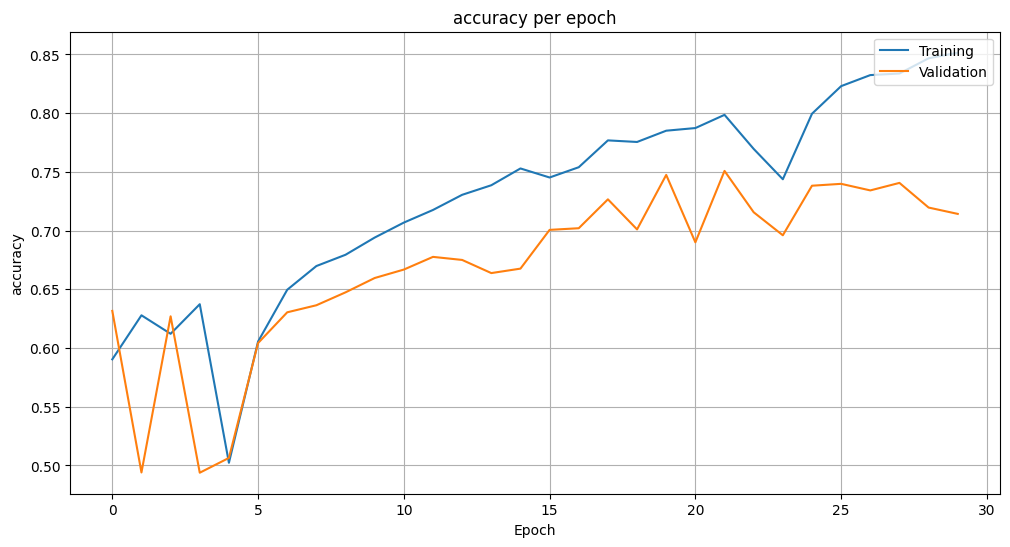

In [26]:
plt.figure(figsize=(12, 6))
plt.plot(history_RNN_HE.history['accuracy'])
plt.plot(history_RNN_HE.history['val_accuracy'])
plt.title('accuracy per epoch')
plt.ylabel('accuracy')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper right')
plt.grid()
plt.show()

In [27]:
RNN_HE.evaluate(X_test, y_test)


782/782 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - accuracy: 0.7384 - loss: 0.5294


[0.5337895750999451, 0.737559974193573]

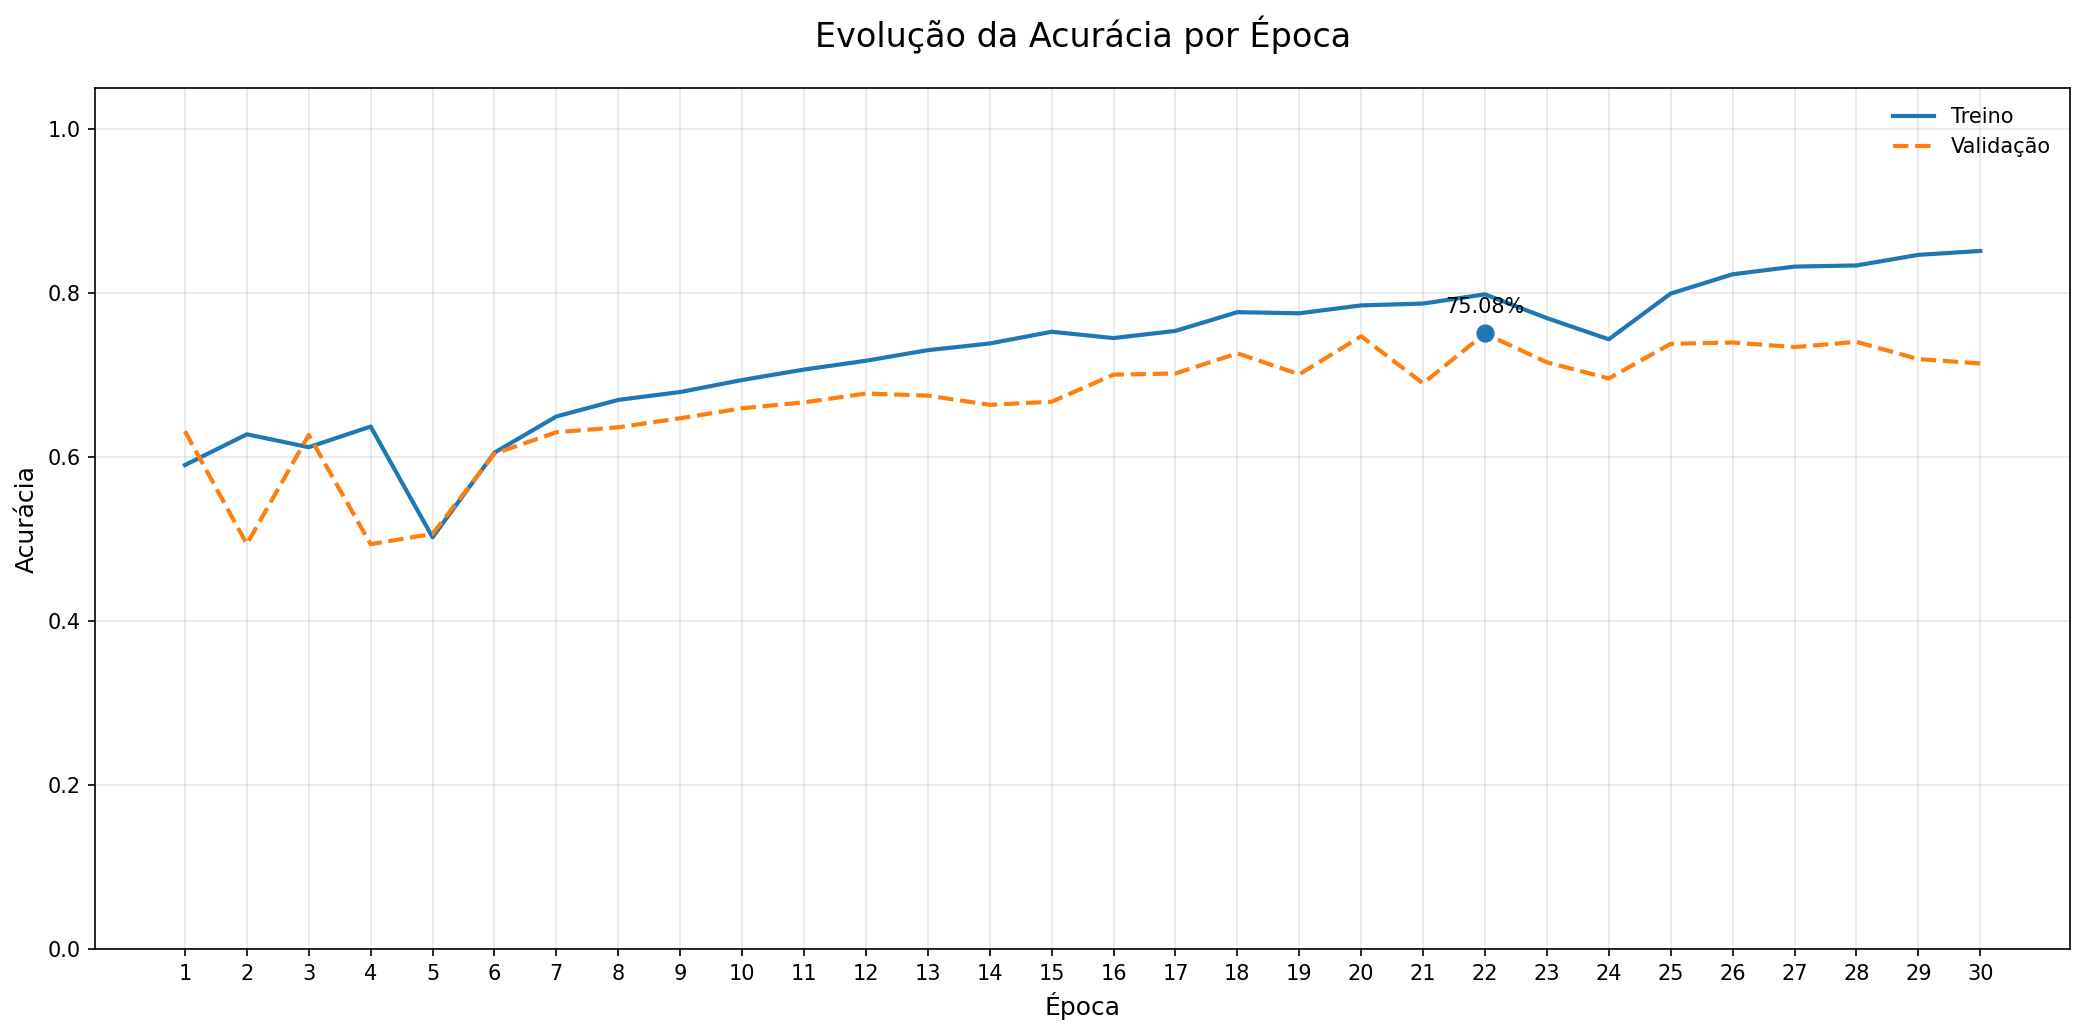

In [28]:
# ─── DADOS ──────────────────────────────────────────────────────────────────────
train_acc = history_RNN_HE.history['accuracy']
val_acc   = history_RNN_HE.history['val_accuracy']
epochs    = range(1, len(train_acc) + 1)

# ─── FIGURA ─────────────────────────────────────────────────────────────────────
plt.figure(figsize=(14, 7), dpi=150)

# Curva de treino
plt.plot(epochs, train_acc,
         label='Treino',
         linewidth=2)

# Curva de validação
plt.plot(epochs, val_acc,
         label='Validação',
         linewidth=2,
         linestyle='--')

# ─── REALCES ÚTEIS ──────────────────────────────────────────────────────────────
# Aponta a melhor época na validação
best_ep   = max(range(len(val_acc)), key=val_acc.__getitem__)
best_val  = val_acc[best_ep]
plt.scatter(best_ep + 1, best_val, s=60, zorder=5)
plt.text(best_ep + 1, best_val + 0.02,
         f'{best_val:.2%}',
         ha='center', va='bottom', fontsize=10)

# ─── ESTILO GERAL ───────────────────────────────────────────────────────────────
plt.title('Evolução da Acurácia por Época', fontsize=16, pad=20)
plt.xlabel('Época', fontsize=12)
plt.ylabel('Acurácia', fontsize=12)
plt.xticks(epochs)              # mostra todas as épocas no eixo-x
plt.ylim(0, 1.05)               # garante visibilidade até 100 %
plt.grid(alpha=0.3)             # grid suave
plt.legend(frameon=False)       # sem moldura no legend
plt.tight_layout()              # encaixa tudo

plt.show()

## GLorot

In [29]:
tf.keras.backend.clear_session()
tf.random.set_seed(42)

In [30]:
RNN_GL= Sequential()
RNN_GL.add(Embedding(max_features, 128, input_length=max_length, input_shape=X_train.shape[1:]))
RNN_GL.add(SimpleRNN(128, return_sequences=True,activation="tanh", kernel_initializer=initializer_2))
RNN_GL.add(SimpleRNN(128, return_sequences=False,activation="tanh", kernel_initializer=initializer_2))
RNN_GL.add(Dense(1, activation='sigmoid'))

RNN_GL.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 500, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 500, 128)       │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,345,921 (5.13 MB)

 Trainable params: 1,345,921 (5.13 MB)

 Non-trainable params: 0 (0.00 B)

In [31]:
early_stopping= EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

In [32]:
Optimizer= Adam(learning_rate=0.001)

RNN_GL.compile(loss='binary_crossentropy', 
               optimizer=Optimizer, 
               metrics=['accuracy'])

In [33]:
history_RNN_GL= RNN_GL.fit(X_train, y_train, 
                           epochs=500, 
                           batch_size=256, 
                           validation_split=0.2, 
                           callbacks=[early_stopping], 
                           verbose=1)

Epoch 1/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 30s 370ms/step - accuracy: 0.5071 - loss: 0.7199 - val_accuracy: 0.5802 - val_loss: 0.6753
Epoch 2/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 29s 368ms/step - accuracy: 0.5859 - loss: 0.6622 - val_accuracy: 0.7022 - val_loss: 0.5808
Epoch 3/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 29s 368ms/step - accuracy: 0.7586 - loss: 0.4938 - val_accuracy: 0.6492 - val_loss: 0.7808
Epoch 4/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 29s 369ms/step - accuracy: 0.7858 - loss: 0.4563 - val_accuracy: 0.8032 - val_loss: 0.4443
Epoch 5/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 29s 372ms/step - accuracy: 0.8849 - loss: 0.2806 - val_accuracy: 0.8142 - val_loss: 0.4710
Epoch 6/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 29s 370ms/step - accuracy: 0.9295 - loss: 0.1870 - val_accuracy: 0.8044 - val_loss: 0.5699
Epoch 7/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 29s 370ms/step - accuracy: 0.9546 - loss: 0.1350 - val_accuracy: 0.8174 - val_loss: 0.6841
Epoch 8/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 29s 370ms/step - accuracy: 0.9334 - loss: 0.1820 - 

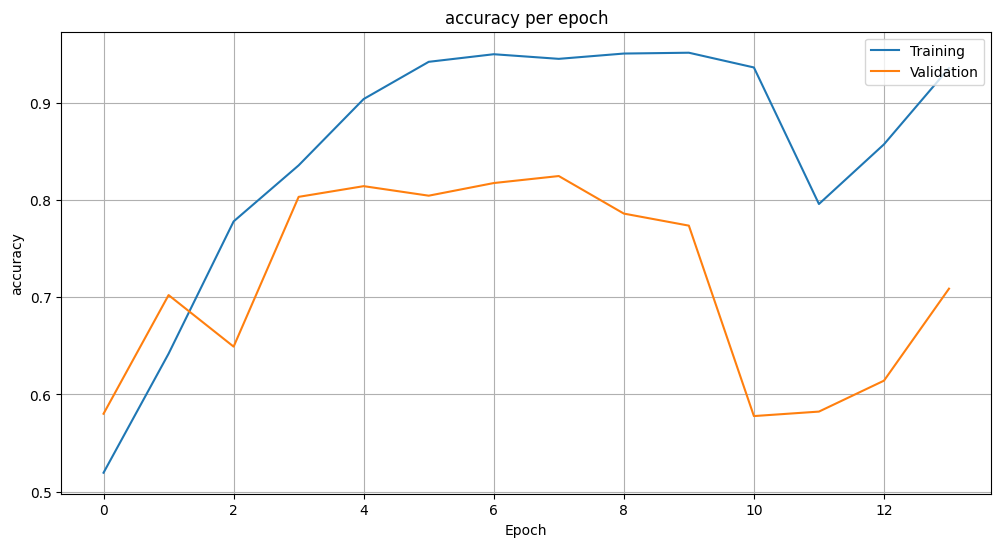

In [34]:
plt.figure(figsize=(12, 6))
plt.plot(history_RNN_GL.history['accuracy'])
plt.plot(history_RNN_GL.history['val_accuracy'])
plt.title('accuracy per epoch')
plt.ylabel('accuracy')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper right')
plt.grid()
plt.show()

In [35]:
RNN_GL.evaluate(X_test, y_test)

782/782 ━━━━━━━━━━━━━━━━━━━━ 17s 22ms/step - accuracy: 0.8103 - loss: 0.4418


[0.43694695830345154, 0.8109999895095825]

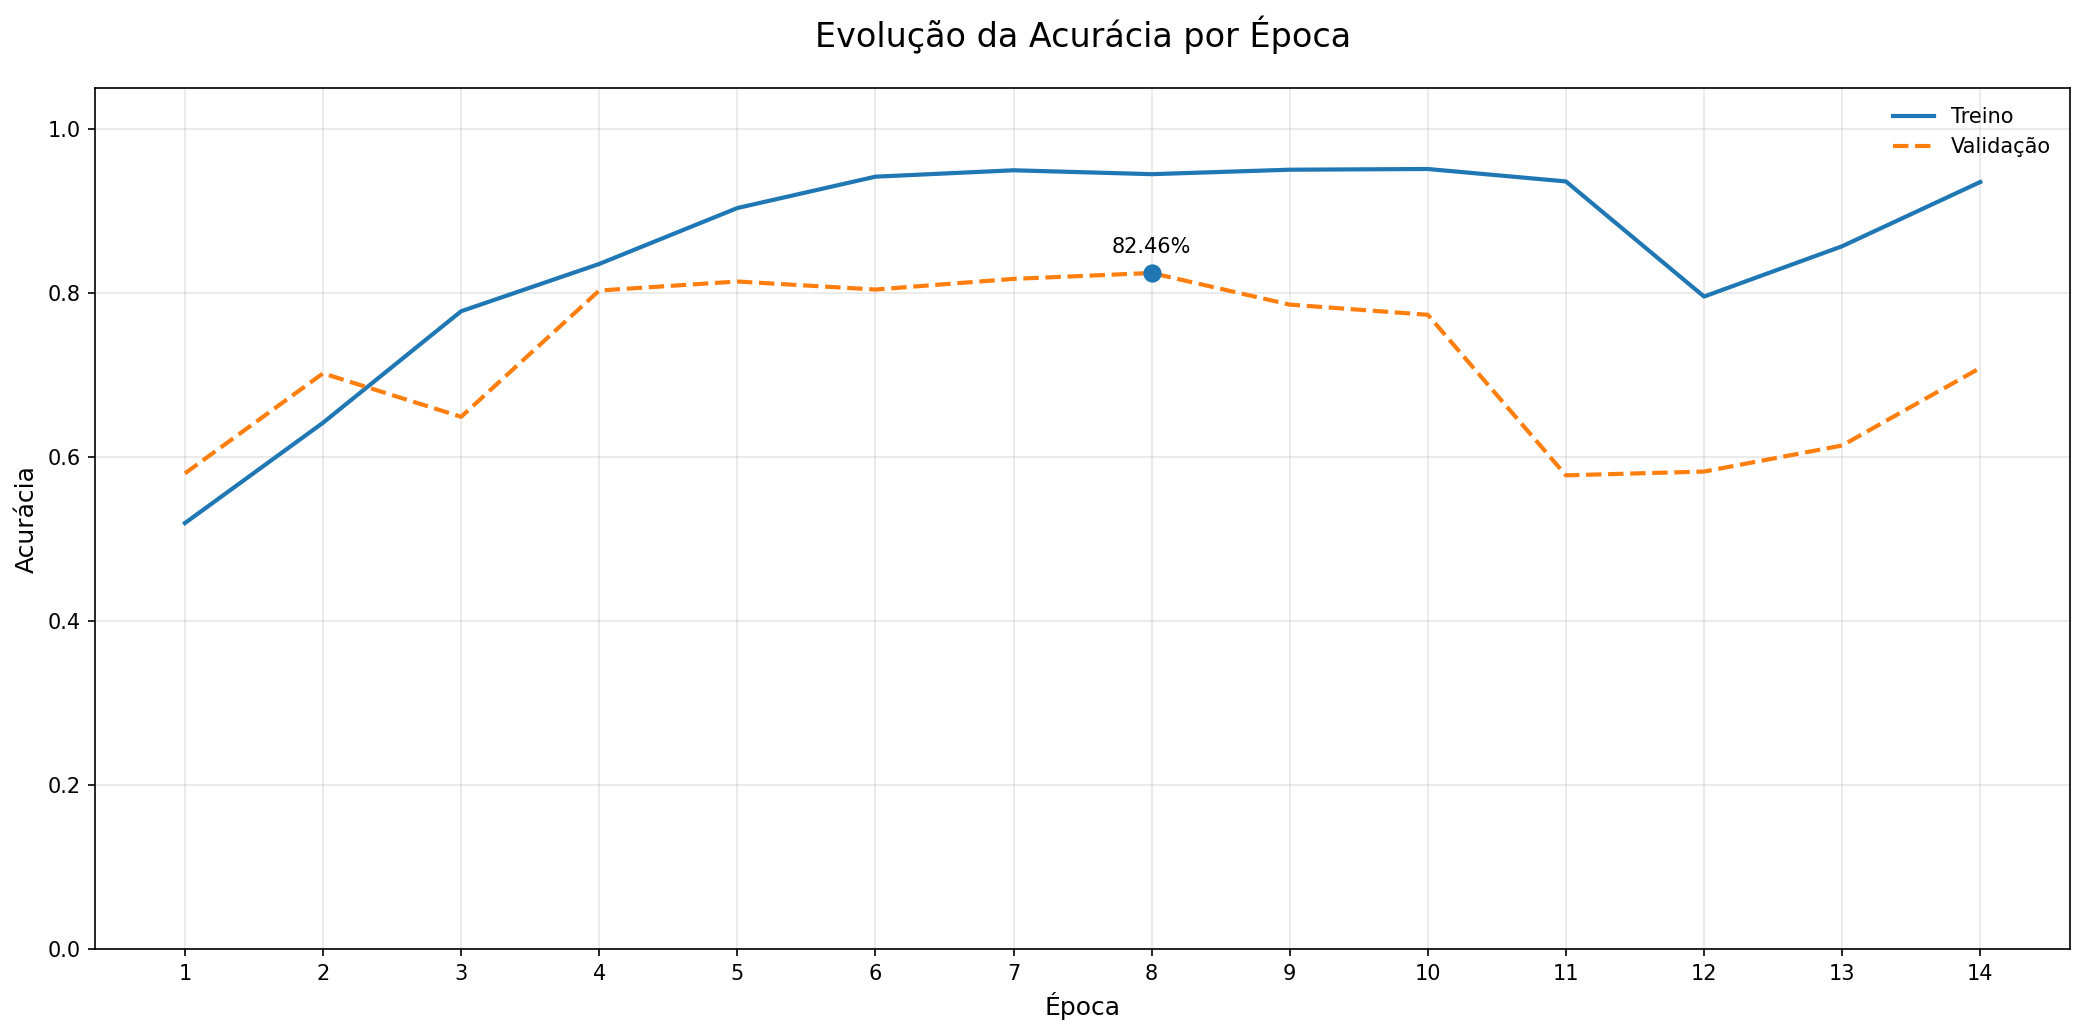

In [36]:
# ─── DADOS ──────────────────────────────────────────────────────────────────────
train_acc = history_RNN_GL.history['accuracy']
val_acc   = history_RNN_GL.history['val_accuracy']
epochs    = range(1, len(train_acc) + 1)

# ─── FIGURA ─────────────────────────────────────────────────────────────────────
plt.figure(figsize=(14, 7), dpi=150)

# Curva de treino
plt.plot(epochs, train_acc,
         label='Treino',
         linewidth=2)

# Curva de validação
plt.plot(epochs, val_acc,
         label='Validação',
         linewidth=2,
         linestyle='--')

# ─── REALCES ÚTEIS ──────────────────────────────────────────────────────────────
# Aponta a melhor época na validação
best_ep   = max(range(len(val_acc)), key=val_acc.__getitem__)
best_val  = val_acc[best_ep]
plt.scatter(best_ep + 1, best_val, s=60, zorder=5)
plt.text(best_ep + 1, best_val + 0.02,
         f'{best_val:.2%}',
         ha='center', va='bottom', fontsize=10)

# ─── ESTILO GERAL ───────────────────────────────────────────────────────────────
plt.title('Evolução da Acurácia por Época', fontsize=16, pad=20)
plt.xlabel('Época', fontsize=12)
plt.ylabel('Acurácia', fontsize=12)
plt.xticks(epochs)              # mostra todas as épocas no eixo-x
plt.ylim(0, 1.05)               # garante visibilidade até 100 %
plt.grid(alpha=0.3)             # grid suave
plt.legend(frameon=False)       # sem moldura no legend
plt.tight_layout()              # encaixa tudo

plt.show()


## LeCun

In [37]:
tf.keras.backend.clear_session()
tf.random.set_seed(42)

In [38]:
RNN_LE= Sequential()
RNN_LE.add(Embedding(max_features, 128, input_length=max_length, input_shape=X_train.shape[1:]))
RNN_LE.add(SimpleRNN(128, return_sequences=True,activation="tanh", kernel_initializer=initializer_3))
RNN_LE.add(SimpleRNN(128, return_sequences=False,activation="tanh", kernel_initializer=initializer_3))
RNN_LE.add(Dense(1, activation='sigmoid'))

RNN_LE.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 500, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 500, 128)       │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,345,921 (5.13 MB)

 Trainable params: 1,345,921 (5.13 MB)

 Non-trainable params: 0 (0.00 B)

In [39]:
early_stopping= EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
Optimizer= Adam(learning_rate=0.001)

RNN_LE.compile(loss='binary_crossentropy', 
               optimizer=Optimizer, 
               metrics=['accuracy'])

In [40]:
history_RNN_LE= RNN_LE.fit(X_train, y_train, 
                           epochs=500, 
                           batch_size=256, 
                           validation_split=0.2, 
                           callbacks=[early_stopping], 
                           verbose=1)

Epoch 1/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 30s 369ms/step - accuracy: 0.5205 - loss: 0.7113 - val_accuracy: 0.6340 - val_loss: 0.6468
Epoch 2/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 29s 372ms/step - accuracy: 0.7523 - loss: 0.5218 - val_accuracy: 0.7070 - val_loss: 0.5562
Epoch 3/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 30s 377ms/step - accuracy: 0.7081 - loss: 0.5566 - val_accuracy: 0.7348 - val_loss: 0.5375
Epoch 4/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 30s 374ms/step - accuracy: 0.8442 - loss: 0.3490 - val_accuracy: 0.7832 - val_loss: 0.5018
Epoch 5/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 30s 378ms/step - accuracy: 0.8346 - loss: 0.3675 - val_accuracy: 0.6812 - val_loss: 0.7952
Epoch 6/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 30s 379ms/step - accuracy: 0.9105 - loss: 0.2235 - val_accuracy: 0.6850 - val_loss: 0.7639
Epoch 7/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 30s 382ms/step - accuracy: 0.9498 - loss: 0.1382 - val_accuracy: 0.7488 - val_loss: 0.7259
Epoch 8/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 30s 383ms/step - accuracy: 0.9595 - loss: 0.1110 - 

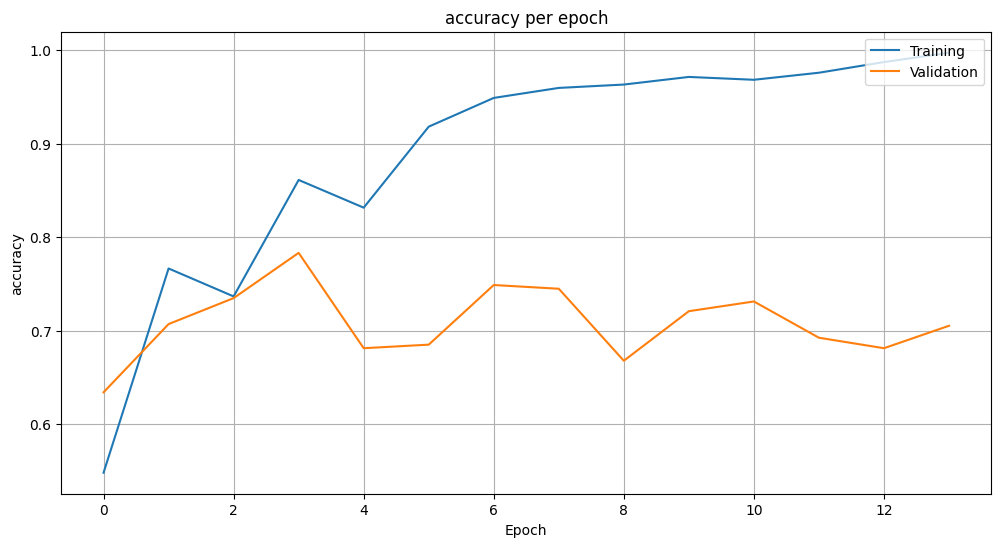

In [41]:
plt.figure(figsize=(12, 6))
plt.plot(history_RNN_LE.history['accuracy'])
plt.plot(history_RNN_LE.history['val_accuracy'])
plt.title('accuracy per epoch')
plt.ylabel('accuracy')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper right')
plt.grid()
plt.show()

In [42]:
RNN_LE.evaluate(X_test, y_test)

782/782 ━━━━━━━━━━━━━━━━━━━━ 17s 22ms/step - accuracy: 0.7804 - loss: 0.5113


[0.5005099773406982, 0.7843599915504456]

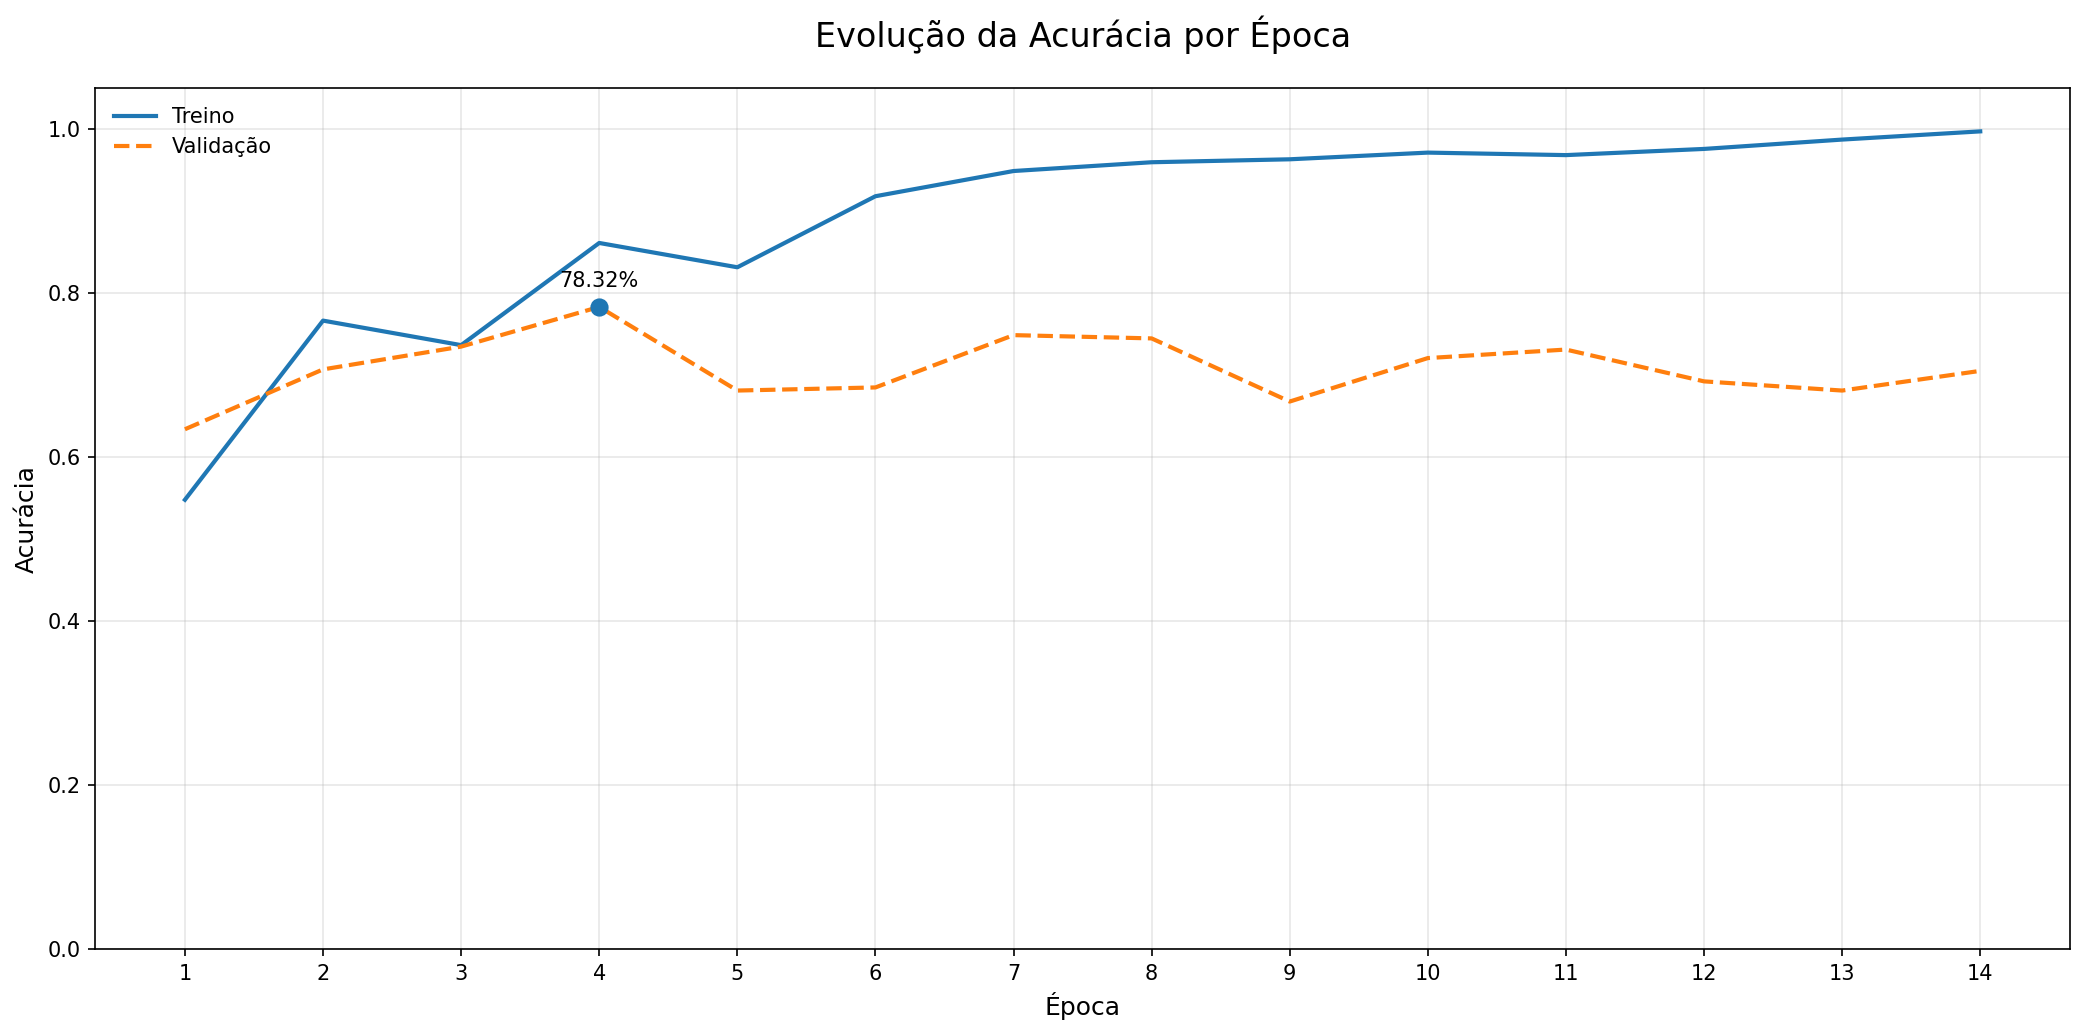

In [43]:


# ─── DADOS ──────────────────────────────────────────────────────────────────────
train_acc = history_RNN_LE.history['accuracy']
val_acc   = history_RNN_LE.history['val_accuracy']
epochs    = range(1, len(train_acc) + 1)

# ─── FIGURA ─────────────────────────────────────────────────────────────────────
plt.figure(figsize=(14, 7), dpi=150)

# Curva de treino
plt.plot(epochs, train_acc,
         label='Treino',
         linewidth=2)

# Curva de validação
plt.plot(epochs, val_acc,
         label='Validação',
         linewidth=2,
         linestyle='--')

# ─── REALCES ÚTEIS ──────────────────────────────────────────────────────────────
# Aponta a melhor época na validação
best_ep   = max(range(len(val_acc)), key=val_acc.__getitem__)
best_val  = val_acc[best_ep]
plt.scatter(best_ep + 1, best_val, s=60, zorder=5)
plt.text(best_ep + 1, best_val + 0.02,
         f'{best_val:.2%}',
         ha='center', va='bottom', fontsize=10)

# ─── ESTILO GERAL ───────────────────────────────────────────────────────────────
plt.title('Evolução da Acurácia por Época', fontsize=16, pad=20)
plt.xlabel('Época', fontsize=12)
plt.ylabel('Acurácia', fontsize=12)
plt.xticks(epochs)              # mostra todas as épocas no eixo-x
plt.ylim(0, 1.05)               # garante visibilidade até 100 %
plt.grid(alpha=0.3)             # grid suave
plt.legend(frameon=False)       # sem moldura no legend
plt.tight_layout()              # encaixa tudo

plt.show()


# LSTM

## HE 

In [44]:
tf.keras.backend.clear_session()
tf.random.set_seed(42)

In [45]:
LSTM_HE= Sequential()
LSTM_HE.add(Embedding(max_features, 128, input_length=max_length, input_shape=X_train.shape[1:]))
LSTM_HE.add(LSTM(64, return_sequences=True,activation="relu", kernel_initializer=initializer_1))
LSTM_HE.add(LSTM(64, return_sequences=False,activation="relu", kernel_initializer=initializer_1))
LSTM_HE.add(Dense(1, activation='sigmoid'))

LSTM_HE.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 500, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 500, 64)        │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,362,497 (5.20 MB)

 Trainable params: 1,362,497 (5.20 MB)

 Non-trainable params: 0 (0.00 B)

In [46]:
early_stopping= EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

Optimizer= Adam(learning_rate=0.001)

LSTM_HE.compile(loss='binary_crossentropy', 
               optimizer=Optimizer, 
               metrics=['accuracy'])

In [47]:
history_LSTM_HE= LSTM_HE.fit(X_train, y_train, 
                           epochs=500, 
                           batch_size=256, 
                           validation_split=0.2, 
                           callbacks=[early_stopping], 
                           verbose=1)

Epoch 1/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 94s 1s/step - accuracy: 0.5553 - loss: nan - val_accuracy: 0.5062 - val_loss: nan
Epoch 2/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 99s 1s/step - accuracy: 0.4999 - loss: nan - val_accuracy: 0.5062 - val_loss: nan
Epoch 3/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 101s 1s/step - accuracy: 0.4999 - loss: nan - val_accuracy: 0.5062 - val_loss: nan
Epoch 4/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 105s 1s/step - accuracy: 0.4999 - loss: nan - val_accuracy: 0.5062 - val_loss: nan
Epoch 5/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 107s 1s/step - accuracy: 0.4999 - loss: nan - val_accuracy: 0.5062 - val_loss: nan
Epoch 6/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 109s 1s/step - accuracy: 0.4999 - loss: nan - val_accuracy: 0.5062 - val_loss: nan
Epoch 7/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 111s 1s/step - accuracy: 0.4999 - loss: nan - val_accuracy: 0.5062 - val_loss: nan
Epoch 8/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 112s 1s/step - accuracy: 0.4999 - loss: nan - val_accuracy: 0.5062 - val_loss: nan
Epoch 9/500
79/79 ━━━━━━━━

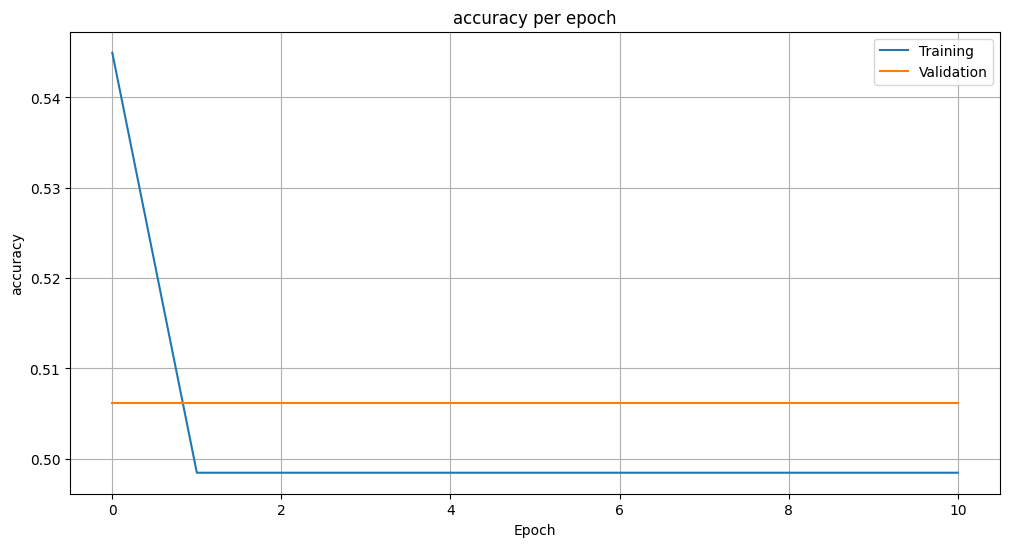

In [48]:
plt.figure(figsize=(12, 6))
plt.plot(history_LSTM_HE.history['accuracy'])
plt.plot(history_LSTM_HE.history['val_accuracy'])
plt.title('accuracy per epoch')
plt.ylabel('accuracy')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper right')
plt.grid()
plt.show()

In [49]:
LSTM_HE.evaluate(X_test, y_test)

782/782 ━━━━━━━━━━━━━━━━━━━━ 59s 76ms/step - accuracy: 0.5073 - loss: nan


[nan, 0.5]

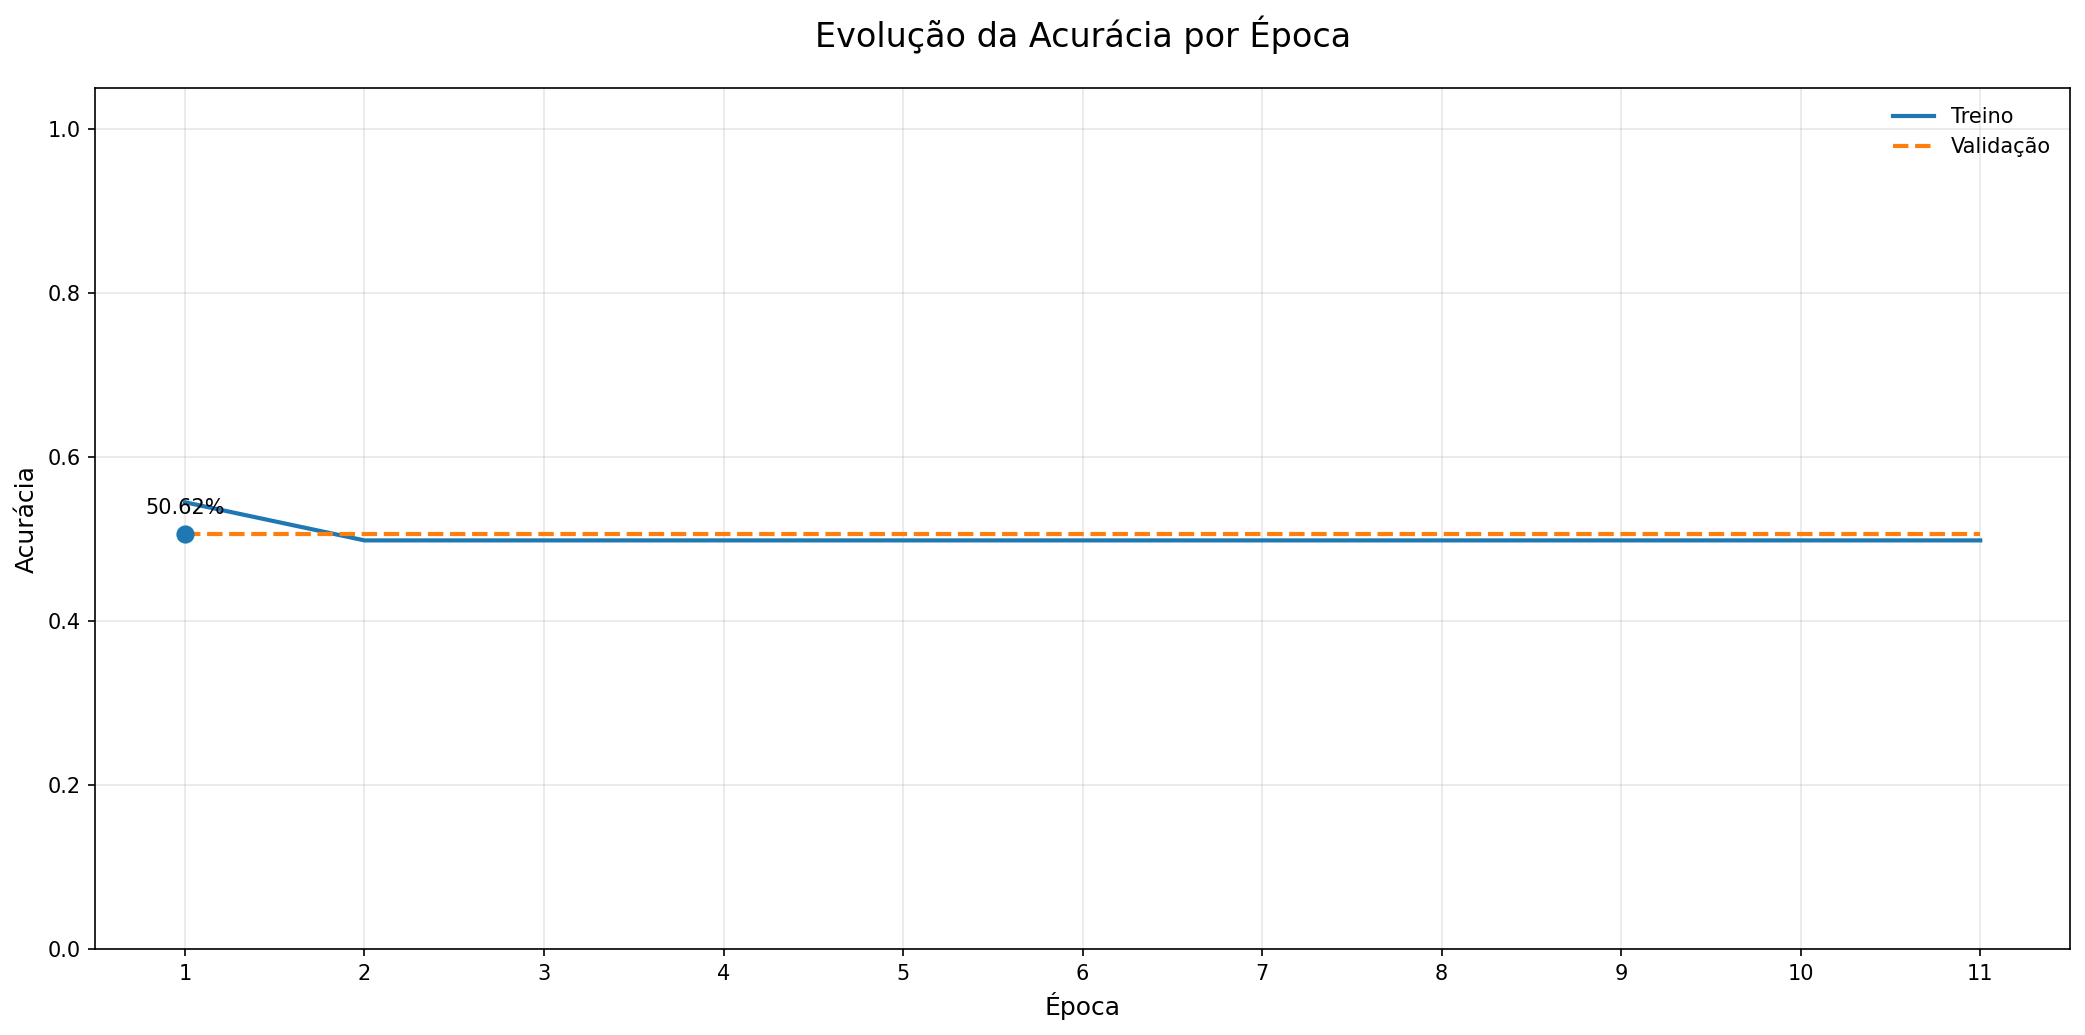

In [50]:
# ─── DADOS ──────────────────────────────────────────────────────────────────────
train_acc = history_LSTM_HE.history['accuracy']
val_acc   = history_LSTM_HE.history['val_accuracy']
epochs    = range(1, len(train_acc) + 1)

# ─── FIGURA ─────────────────────────────────────────────────────────────────────
plt.figure(figsize=(14, 7), dpi=150)

# Curva de treino
plt.plot(epochs, train_acc,
         label='Treino',
         linewidth=2)

# Curva de validação
plt.plot(epochs, val_acc,
         label='Validação',
         linewidth=2,
         linestyle='--')

# ─── REALCES ÚTEIS ──────────────────────────────────────────────────────────────
# Aponta a melhor época na validação
best_ep   = max(range(len(val_acc)), key=val_acc.__getitem__)
best_val  = val_acc[best_ep]
plt.scatter(best_ep + 1, best_val, s=60, zorder=5)
plt.text(best_ep + 1, best_val + 0.02,
         f'{best_val:.2%}',
         ha='center', va='bottom', fontsize=10)

# ─── ESTILO GERAL ───────────────────────────────────────────────────────────────
plt.title('Evolução da Acurácia por Época', fontsize=16, pad=20)
plt.xlabel('Época', fontsize=12)
plt.ylabel('Acurácia', fontsize=12)
plt.xticks(epochs)              # mostra todas as épocas no eixo-x
plt.ylim(0, 1.05)               # garante visibilidade até 100 %
plt.grid(alpha=0.3)             # grid suave
plt.legend(frameon=False)       # sem moldura no legend
plt.tight_layout()              # encaixa tudo

plt.show()


## GLorot

In [51]:
tf.keras.backend.clear_session()
tf.random.set_seed(42)

In [52]:
LSTM_GL= Sequential()
LSTM_GL.add(Embedding(max_features, 128, input_length=max_length, input_shape=X_train.shape[1:]))
LSTM_GL.add(LSTM(64, return_sequences=True,activation="tanh", kernel_initializer=initializer_2))
LSTM_GL.add(LSTM(64, return_sequences=False,activation="tanh", kernel_initializer=initializer_2))
LSTM_GL.add(Dense(1, activation='sigmoid'))

LSTM_GL.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 500, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 500, 64)        │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,362,497 (5.20 MB)

 Trainable params: 1,362,497 (5.20 MB)

 Non-trainable params: 0 (0.00 B)

In [53]:
early_stopping= EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
Optimizer= Adam(learning_rate=0.001)

LSTM_GL.compile(loss='binary_crossentropy', 
               optimizer=Optimizer, 
               metrics=['accuracy'])

In [54]:
history_LSTM_GL= LSTM_GL.fit(X_train, y_train, 
                           epochs=500, 
                           batch_size=256, 
                           validation_split=0.2, 
                           callbacks=[early_stopping], 
                           verbose=1)

Epoch 1/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 104s 1s/step - accuracy: 0.6477 - loss: 0.5983 - val_accuracy: 0.8262 - val_loss: 0.3823
Epoch 2/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 103s 1s/step - accuracy: 0.8784 - loss: 0.2892 - val_accuracy: 0.8680 - val_loss: 0.3606
Epoch 3/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 102s 1s/step - accuracy: 0.9183 - loss: 0.2167 - val_accuracy: 0.8586 - val_loss: 0.3461
Epoch 4/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 102s 1s/step - accuracy: 0.9325 - loss: 0.1797 - val_accuracy: 0.8670 - val_loss: 0.3887
Epoch 5/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 102s 1s/step - accuracy: 0.9333 - loss: 0.1766 - val_accuracy: 0.8084 - val_loss: 0.4143
Epoch 6/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 102s 1s/step - accuracy: 0.9079 - loss: 0.2341 - val_accuracy: 0.8630 - val_loss: 0.3964
Epoch 7/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 103s 1s/step - accuracy: 0.9506 - loss: 0.1364 - val_accuracy: 0.8476 - val_loss: 0.5160
Epoch 8/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 102s 1s/step - accuracy: 0.9518 - loss: 0.1317 - val_accuracy: 0.

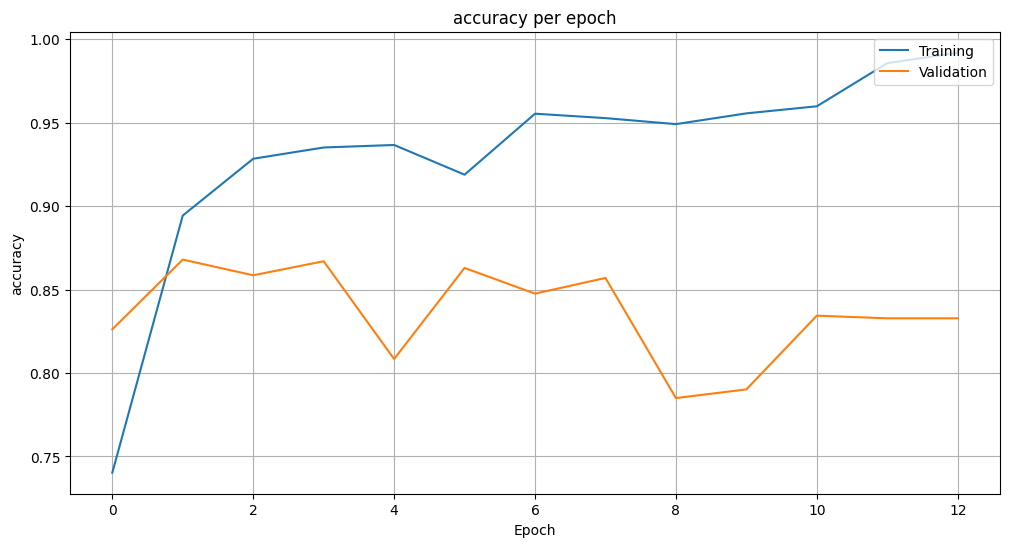

In [55]:
plt.figure(figsize=(12, 6))
plt.plot(history_LSTM_GL.history['accuracy'])
plt.plot(history_LSTM_GL.history['val_accuracy'])
plt.title('accuracy per epoch')
plt.ylabel('accuracy')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper right')
plt.grid()
plt.show()

In [56]:
LSTM_GL.evaluate(X_test, y_test)

782/782 ━━━━━━━━━━━━━━━━━━━━ 36s 46ms/step - accuracy: 0.8533 - loss: 0.3643


[0.35868385434150696, 0.8539599776268005]

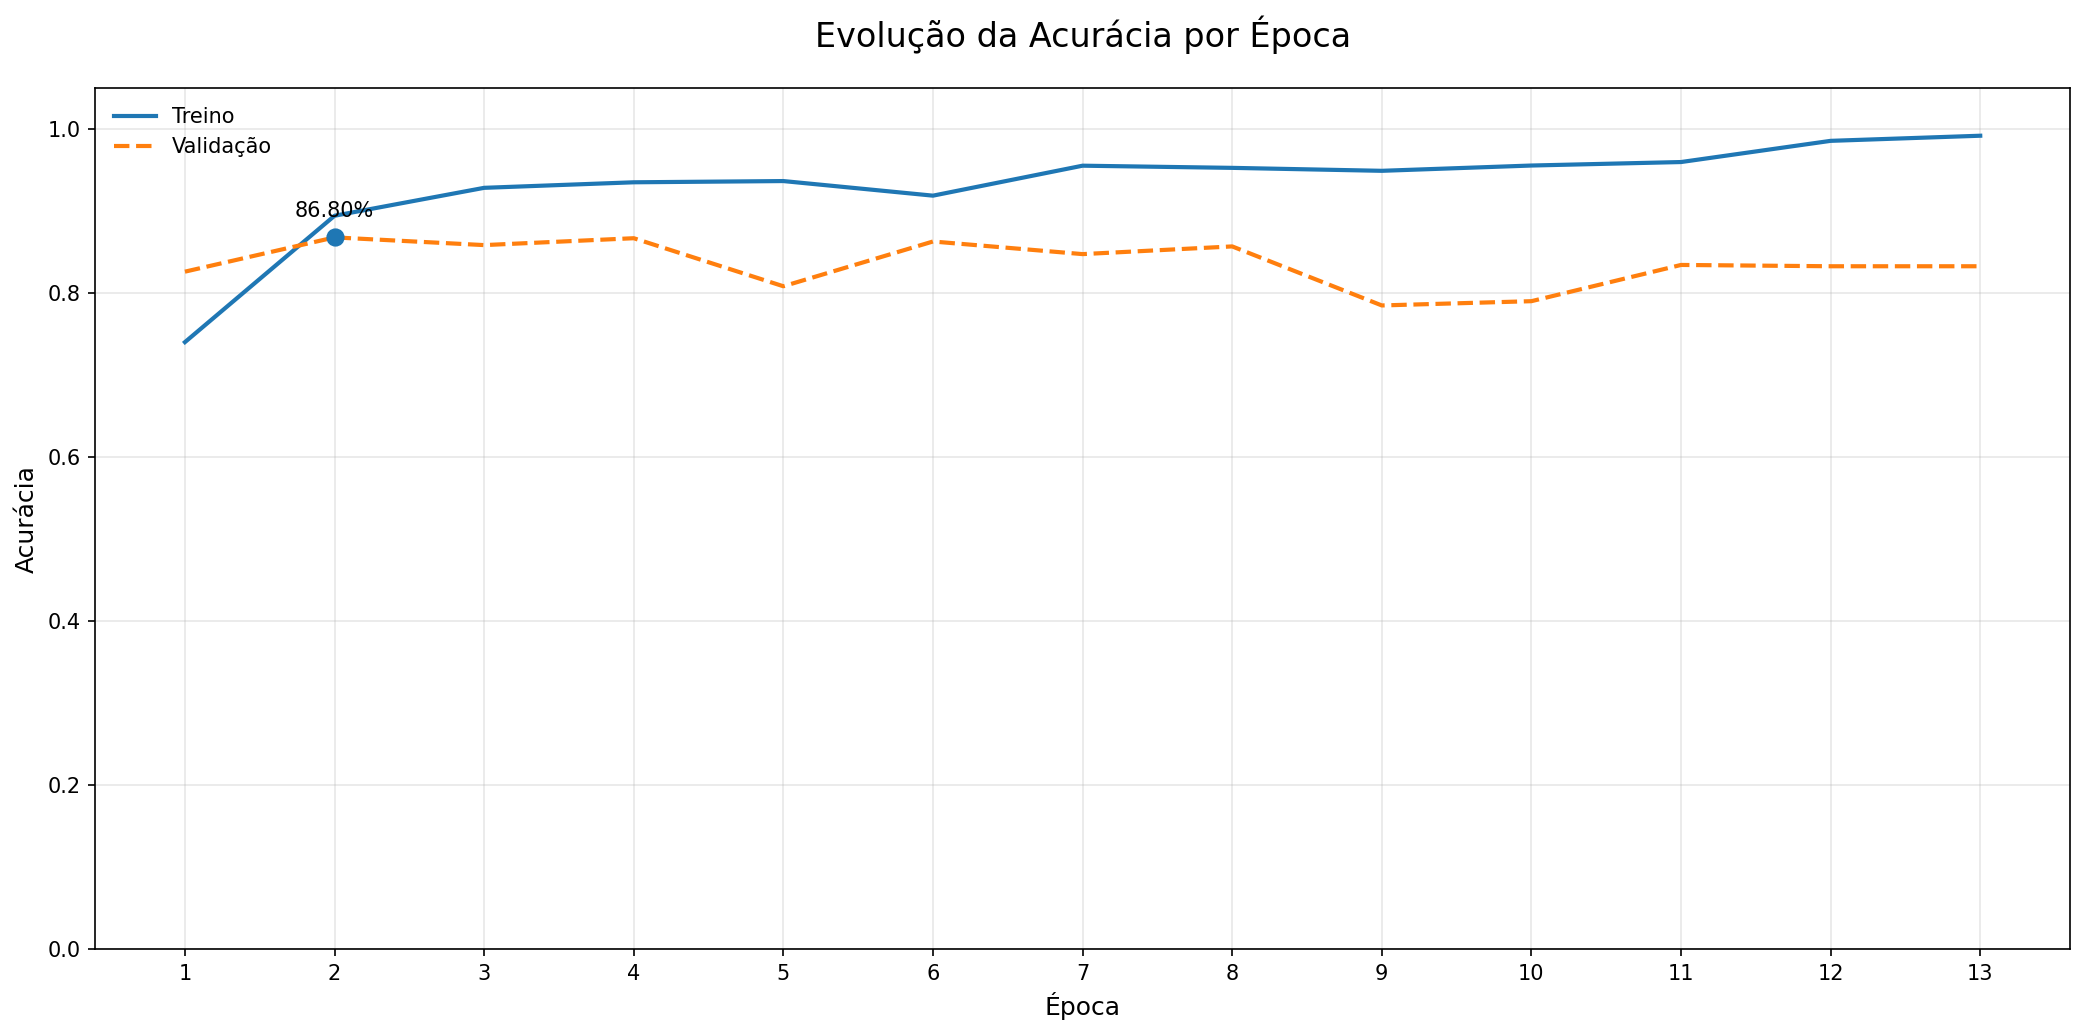

In [57]:
# ─── DADOS ──────────────────────────────────────────────────────────────────────
train_acc = history_LSTM_GL.history['accuracy']
val_acc   = history_LSTM_GL.history['val_accuracy']
epochs    = range(1, len(train_acc) + 1)

# ─── FIGURA ─────────────────────────────────────────────────────────────────────
plt.figure(figsize=(14, 7), dpi=150)

# Curva de treino
plt.plot(epochs, train_acc,
         label='Treino',
         linewidth=2)

# Curva de validação
plt.plot(epochs, val_acc,
         label='Validação',
         linewidth=2,
         linestyle='--')

# ─── REALCES ÚTEIS ──────────────────────────────────────────────────────────────
# Aponta a melhor época na validação
best_ep   = max(range(len(val_acc)), key=val_acc.__getitem__)
best_val  = val_acc[best_ep]
plt.scatter(best_ep + 1, best_val, s=60, zorder=5)
plt.text(best_ep + 1, best_val + 0.02,
         f'{best_val:.2%}',
         ha='center', va='bottom', fontsize=10)

# ─── ESTILO GERAL ───────────────────────────────────────────────────────────────
plt.title('Evolução da Acurácia por Época', fontsize=16, pad=20)
plt.xlabel('Época', fontsize=12)
plt.ylabel('Acurácia', fontsize=12)
plt.xticks(epochs)              # mostra todas as épocas no eixo-x
plt.ylim(0, 1.05)               # garante visibilidade até 100 %
plt.grid(alpha=0.3)             # grid suave
plt.legend(frameon=False)       # sem moldura no legend
plt.tight_layout()              # encaixa tudo

plt.show()





## LeCun

In [58]:
tf.keras.backend.clear_session()
tf.random.set_seed(42)

In [59]:
LSTM_LE= Sequential()
LSTM_LE.add(Embedding(max_features, 128, input_length=max_length, input_shape=X_train.shape[1:]))
LSTM_LE.add(LSTM(64, return_sequences=True,activation="tanh", kernel_initializer=initializer_3))
LSTM_LE.add(LSTM(64, return_sequences=False,activation="tanh", kernel_initializer=initializer_3))
LSTM_LE.add(Dense(1, activation='sigmoid'))

LSTM_LE.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 500, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 500, 64)        │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,362,497 (5.20 MB)

 Trainable params: 1,362,497 (5.20 MB)

 Non-trainable params: 0 (0.00 B)

In [60]:
early_stopping= EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
Optimizer= Adam(learning_rate=0.001)

LSTM_LE.compile(loss='binary_crossentropy', 
               optimizer=Optimizer, 
               metrics=['accuracy'])

In [61]:
history_LSTM_LE= LSTM_LE.fit(X_train, y_train, 
                           epochs=500, 
                           batch_size=256, 
                           validation_split=0.2, 
                           callbacks=[early_stopping], 
                           verbose=1)

Epoch 1/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 101s 1s/step - accuracy: 0.6516 - loss: 0.5949 - val_accuracy: 0.7958 - val_loss: 0.4740
Epoch 2/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 103s 1s/step - accuracy: 0.8614 - loss: 0.3254 - val_accuracy: 0.8606 - val_loss: 0.3542
Epoch 3/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 102s 1s/step - accuracy: 0.9176 - loss: 0.2189 - val_accuracy: 0.8490 - val_loss: 0.3648
Epoch 4/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 103s 1s/step - accuracy: 0.9165 - loss: 0.2118 - val_accuracy: 0.8648 - val_loss: 0.3199
Epoch 5/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 103s 1s/step - accuracy: 0.9316 - loss: 0.1757 - val_accuracy: 0.8220 - val_loss: 0.4716
Epoch 6/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 104s 1s/step - accuracy: 0.9394 - loss: 0.1558 - val_accuracy: 0.8608 - val_loss: 0.4018
Epoch 7/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 103s 1s/step - accuracy: 0.9528 - loss: 0.1304 - val_accuracy: 0.8228 - val_loss: 0.4543
Epoch 8/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 105s 1s/step - accuracy: 0.9438 - loss: 0.1466 - val_accuracy: 0.

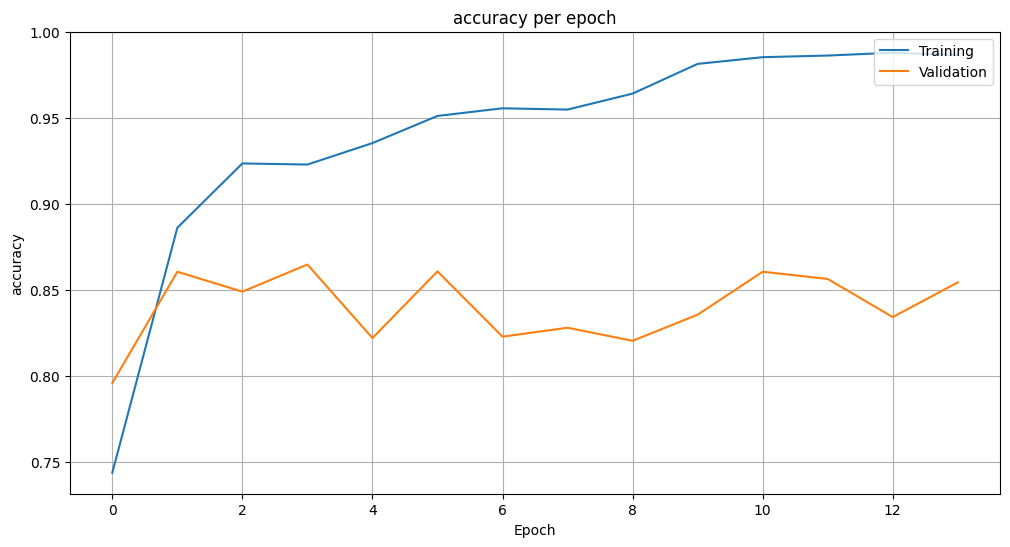

In [62]:
plt.figure(figsize=(12, 6))
plt.plot(history_LSTM_LE.history['accuracy'])
plt.plot(history_LSTM_LE.history['val_accuracy'])
plt.title('accuracy per epoch')
plt.ylabel('accuracy')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper right')
plt.grid()
plt.show()

In [63]:
LSTM_LE.evaluate(X_test, y_test)

782/782 ━━━━━━━━━━━━━━━━━━━━ 36s 46ms/step - accuracy: 0.8624 - loss: 0.3314


[0.3292907178401947, 0.8620799779891968]

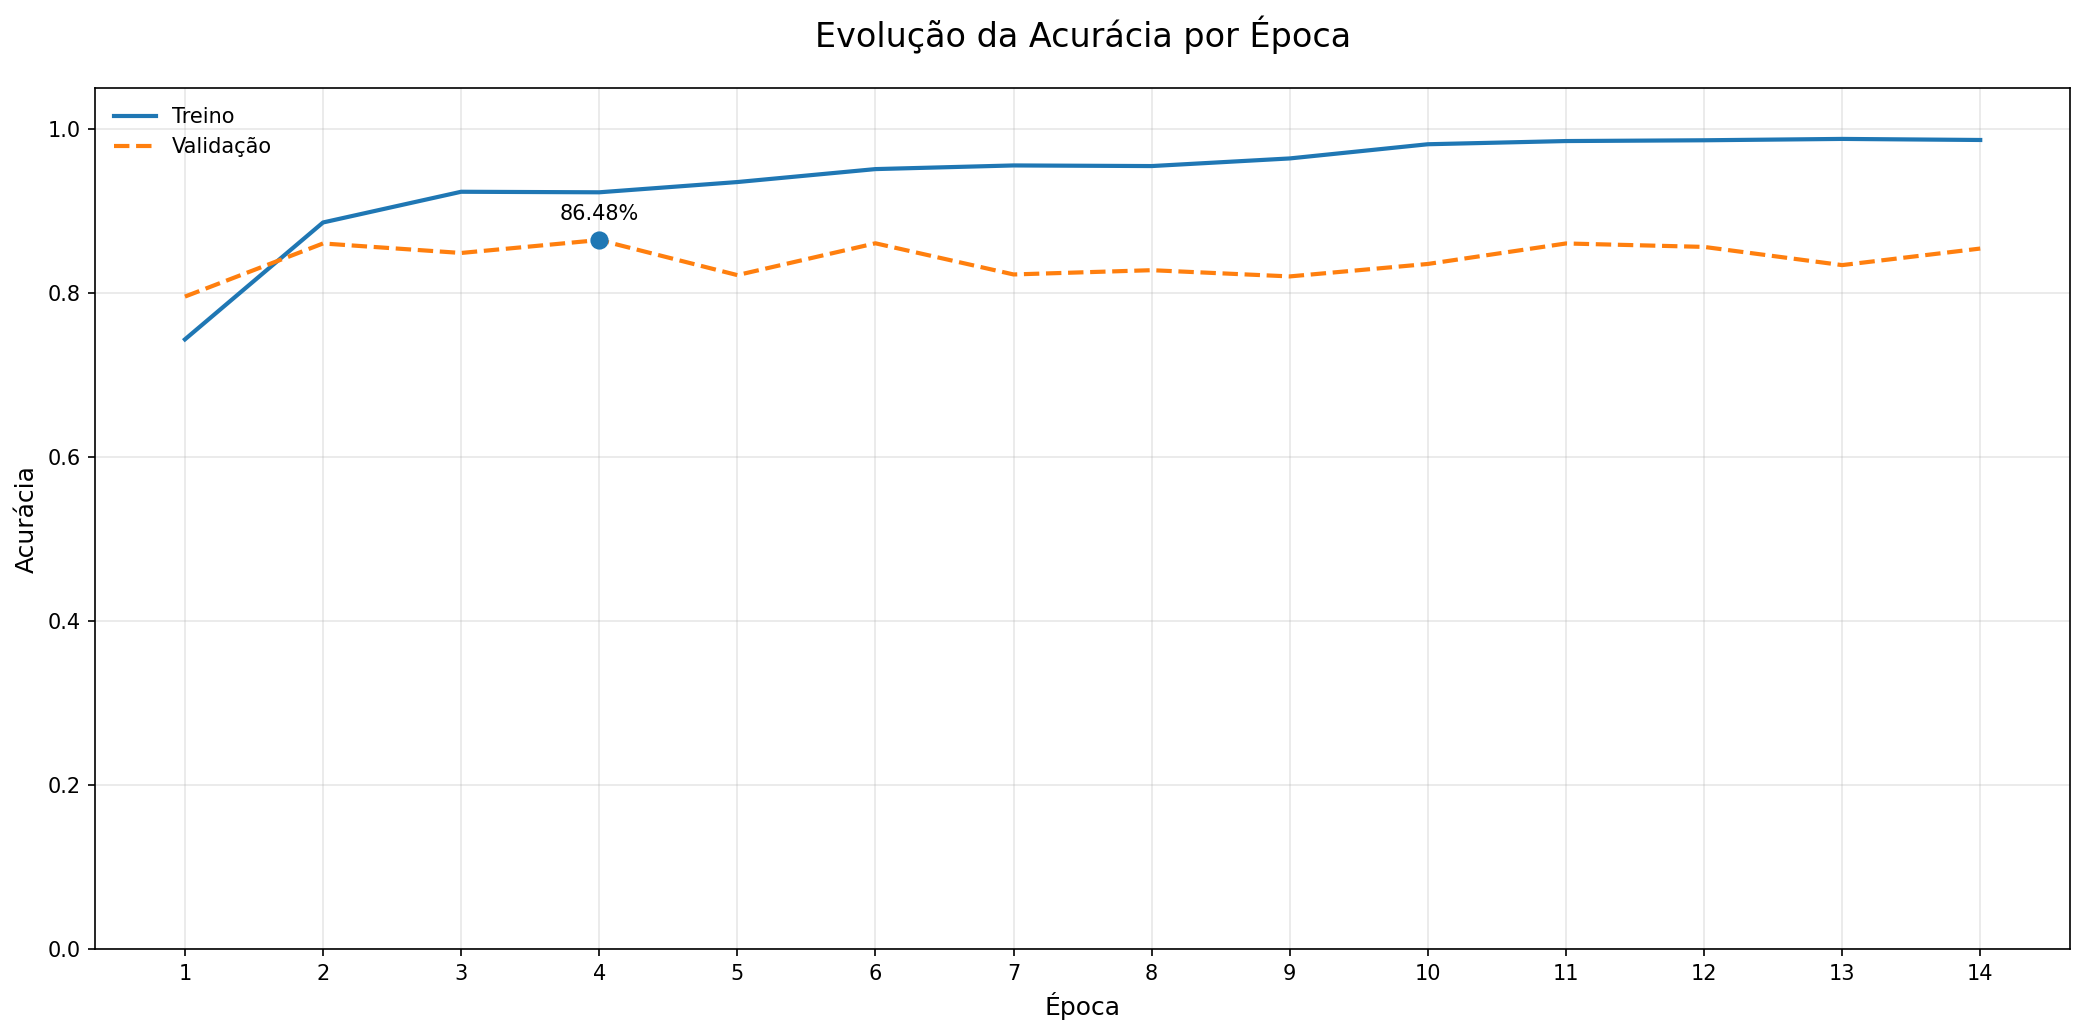

In [64]:
# ─── DADOS ──────────────────────────────────────────────────────────────────────
train_acc = history_LSTM_LE.history['accuracy']
val_acc   = history_LSTM_LE.history['val_accuracy']
epochs    = range(1, len(train_acc) + 1)

# ─── FIGURA ─────────────────────────────────────────────────────────────────────
plt.figure(figsize=(14, 7), dpi=150)

# Curva de treino
plt.plot(epochs, train_acc,
         label='Treino',
         linewidth=2)

# Curva de validação
plt.plot(epochs, val_acc,
         label='Validação',
         linewidth=2,
         linestyle='--')

# ─── REALCES ÚTEIS ──────────────────────────────────────────────────────────────
# Aponta a melhor época na validação
best_ep   = max(range(len(val_acc)), key=val_acc.__getitem__)
best_val  = val_acc[best_ep]
plt.scatter(best_ep + 1, best_val, s=60, zorder=5)
plt.text(best_ep + 1, best_val + 0.02,
         f'{best_val:.2%}',
         ha='center', va='bottom', fontsize=10)

# ─── ESTILO GERAL ───────────────────────────────────────────────────────────────
plt.title('Evolução da Acurácia por Época', fontsize=16, pad=20)
plt.xlabel('Época', fontsize=12)
plt.ylabel('Acurácia', fontsize=12)
plt.xticks(epochs)              # mostra todas as épocas no eixo-x
plt.ylim(0, 1.05)               # garante visibilidade até 100 %
plt.grid(alpha=0.3)             # grid suave
plt.legend(frameon=False)       # sem moldura no legend
plt.tight_layout()              # encaixa tudo

plt.show()


# GRU

## HE

In [65]:
tf.keras.backend.clear_session()
tf.random.set_seed(42)

In [66]:
GRU_HE= Sequential()
GRU_HE.add(Embedding(max_features, 128, input_length=max_length, input_shape=X_train.shape[1:]))
GRU_HE.add(GRU(64, return_sequences=True,activation="relu", kernel_initializer=initializer_1))
GRU_HE.add(GRU(64, return_sequences=False,activation="relu", kernel_initializer=initializer_1))
GRU_HE.add(Dense(1, activation='sigmoid'))

GRU_HE.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 500, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 500, 64)        │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 64)             │        24,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,342,273 (5.12 MB)

 Trainable params: 1,342,273 (5.12 MB)

 Non-trainable params: 0 (0.00 B)

In [67]:
early_stopping= EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

Optimizer= Adam(learning_rate=0.001)

GRU_HE.compile(loss='binary_crossentropy', 
               optimizer=Optimizer, 
               metrics=['accuracy'])

In [68]:
history_GRU_HE= GRU_HE.fit(X_train, y_train, 
                           epochs=500, 
                           batch_size=256, 
                           validation_split=0.2, 
                           callbacks=[early_stopping], 
                           verbose=1)

Epoch 1/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 141s 2s/step - accuracy: 0.6047 - loss: 0.7589 - val_accuracy: 0.6894 - val_loss: 0.5824
Epoch 2/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 149s 2s/step - accuracy: 0.7763 - loss: 0.5136 - val_accuracy: 0.8170 - val_loss: 0.4020
Epoch 3/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 165s 2s/step - accuracy: 0.8648 - loss: 0.3175 - val_accuracy: 0.8572 - val_loss: 0.3347
Epoch 4/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 167s 2s/step - accuracy: 0.9157 - loss: 0.2179 - val_accuracy: 0.8774 - val_loss: 0.3115
Epoch 5/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 166s 2s/step - accuracy: 0.9341 - loss: 0.1796 - val_accuracy: 0.8726 - val_loss: 0.3747
Epoch 6/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 166s 2s/step - accuracy: 0.9398 - loss: 0.1613 - val_accuracy: 0.8784 - val_loss: 0.3654
Epoch 7/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 167s 2s/step - accuracy: 0.9543 - loss: 0.1296 - val_accuracy: 0.8684 - val_loss: 0.4683
Epoch 8/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 167s 2s/step - accuracy: 0.9506 - loss: 0.1360 - val_accuracy: 0.

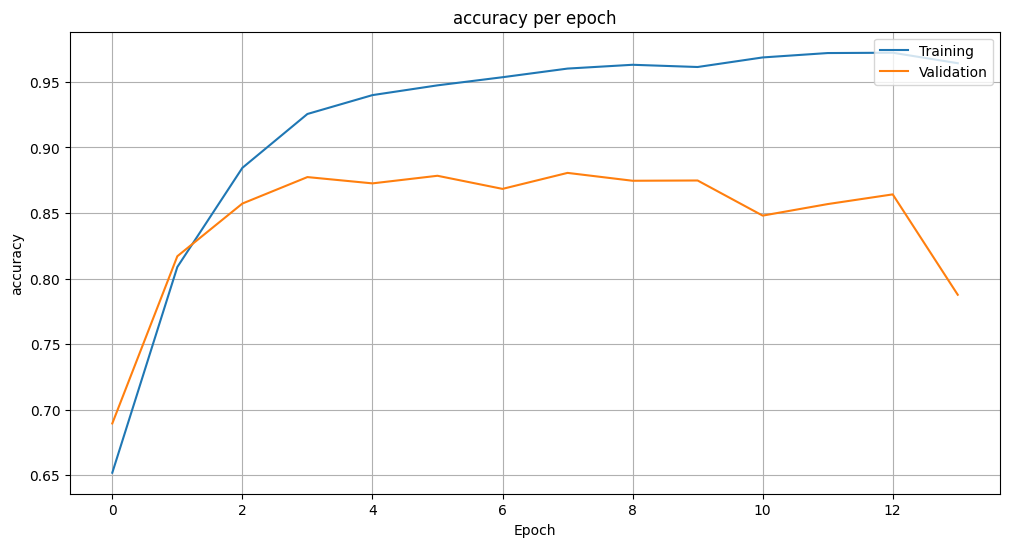

In [69]:
plt.figure(figsize=(12, 6))
plt.plot(history_GRU_HE.history['accuracy'])
plt.plot(history_GRU_HE.history['val_accuracy'])
plt.title('accuracy per epoch')
plt.ylabel('accuracy')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper right')
plt.grid()
plt.show()

In [70]:
GRU_HE.evaluate(X_test, y_test)

782/782 ━━━━━━━━━━━━━━━━━━━━ 48s 61ms/step - accuracy: 0.8629 - loss: 0.3346


[0.3308015763759613, 0.862280011177063]

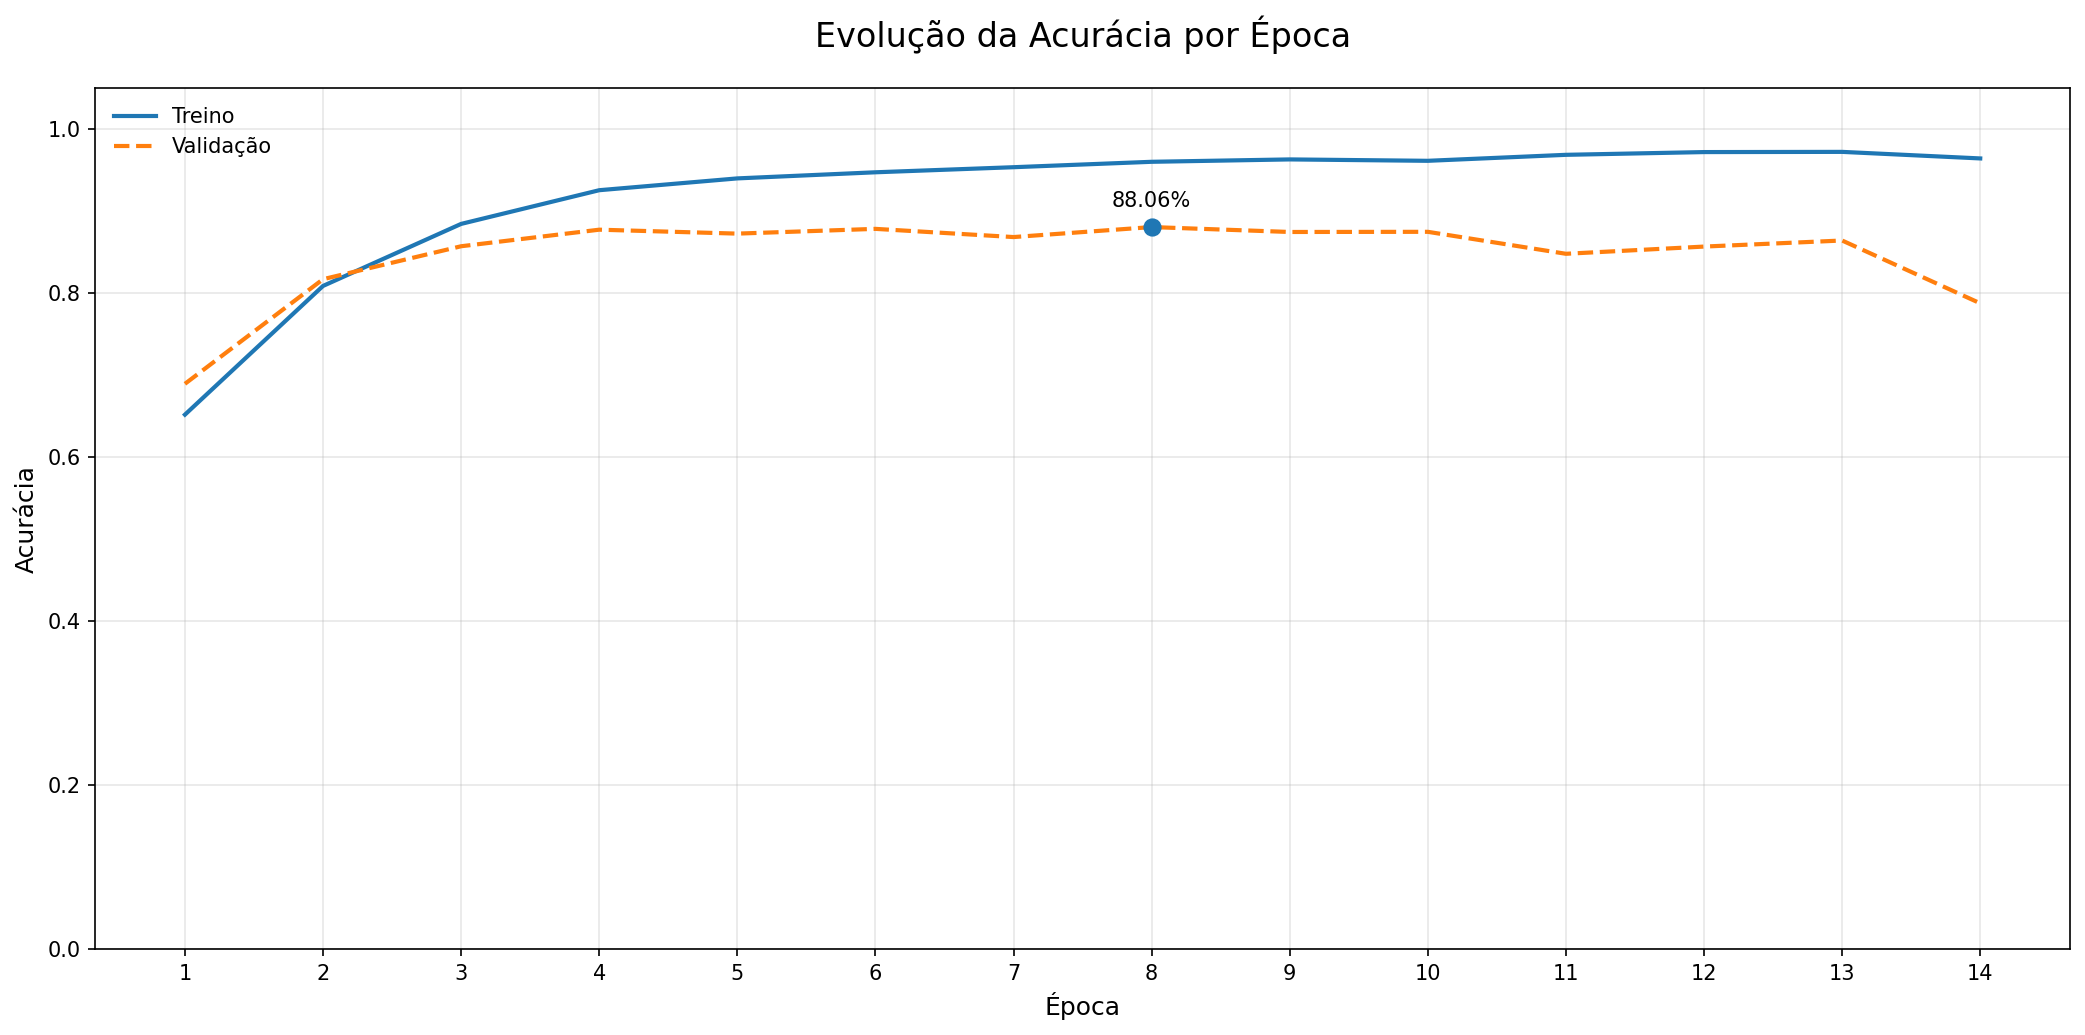

In [71]:
# ─── DADOS ──────────────────────────────────────────────────────────────────────
train_acc = history_GRU_HE.history['accuracy']
val_acc   = history_GRU_HE.history['val_accuracy']
epochs    = range(1, len(train_acc) + 1)

# ─── FIGURA ─────────────────────────────────────────────────────────────────────
plt.figure(figsize=(14, 7), dpi=150)

# Curva de treino
plt.plot(epochs, train_acc,
         label='Treino',
         linewidth=2)

# Curva de validação
plt.plot(epochs, val_acc,
         label='Validação',
         linewidth=2,
         linestyle='--')

# ─── REALCES ÚTEIS ──────────────────────────────────────────────────────────────
# Aponta a melhor época na validação
best_ep   = max(range(len(val_acc)), key=val_acc.__getitem__)
best_val  = val_acc[best_ep]
plt.scatter(best_ep + 1, best_val, s=60, zorder=5)
plt.text(best_ep + 1, best_val + 0.02,
         f'{best_val:.2%}',
         ha='center', va='bottom', fontsize=10)

# ─── ESTILO GERAL ───────────────────────────────────────────────────────────────
plt.title('Evolução da Acurácia por Época', fontsize=16, pad=20)
plt.xlabel('Época', fontsize=12)
plt.ylabel('Acurácia', fontsize=12)
plt.xticks(epochs)              # mostra todas as épocas no eixo-x
plt.ylim(0, 1.05)               # garante visibilidade até 100 %
plt.grid(alpha=0.3)             # grid suave
plt.legend(frameon=False)       # sem moldura no legend
plt.tight_layout()              # encaixa tudo

plt.show()


## GLorot

In [72]:
tf.keras.backend.clear_session()
tf.random.set_seed(42)

In [73]:
GRU_GL= Sequential()
GRU_GL.add(Embedding(max_features, 128, input_length=max_length, input_shape=X_train.shape[1:]))
GRU_GL.add(GRU(64, return_sequences=True,activation="tanh", kernel_initializer=initializer_2))
GRU_GL.add(GRU(64, return_sequences=False,activation="tanh", kernel_initializer=initializer_2))
GRU_GL.add(Dense(1, activation='sigmoid'))

GRU_GL.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 500, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 500, 64)        │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 64)             │        24,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,342,273 (5.12 MB)

 Trainable params: 1,342,273 (5.12 MB)

 Non-trainable params: 0 (0.00 B)

In [74]:
early_stopping= EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
Optimizer= Adam(learning_rate=0.001)

GRU_GL.compile(loss='binary_crossentropy', 
               optimizer=Optimizer, 
               metrics=['accuracy'])

In [75]:
history_GRU_GL= GRU_GL.fit(X_train, y_train, 
                           epochs=500, 
                           batch_size=256, 
                           validation_split=0.2, 
                           callbacks=[early_stopping], 
                           verbose=1)

Epoch 1/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 162s 2s/step - accuracy: 0.6172 - loss: 0.6231 - val_accuracy: 0.8482 - val_loss: 0.3496
Epoch 2/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 160s 2s/step - accuracy: 0.8658 - loss: 0.3213 - val_accuracy: 0.8696 - val_loss: 0.3278
Epoch 3/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 154s 2s/step - accuracy: 0.9022 - loss: 0.2472 - val_accuracy: 0.8180 - val_loss: 0.4189
Epoch 4/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 155s 2s/step - accuracy: 0.9063 - loss: 0.2368 - val_accuracy: 0.8436 - val_loss: 0.4014
Epoch 5/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 158s 2s/step - accuracy: 0.9270 - loss: 0.1911 - val_accuracy: 0.8242 - val_loss: 0.3966
Epoch 6/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 160s 2s/step - accuracy: 0.9441 - loss: 0.1573 - val_accuracy: 0.7922 - val_loss: 0.5037
Epoch 7/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 160s 2s/step - accuracy: 0.9435 - loss: 0.1521 - val_accuracy: 0.7912 - val_loss: 0.6584
Epoch 8/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 156s 2s/step - accuracy: 0.9311 - loss: 0.1807 - val_accuracy: 0.

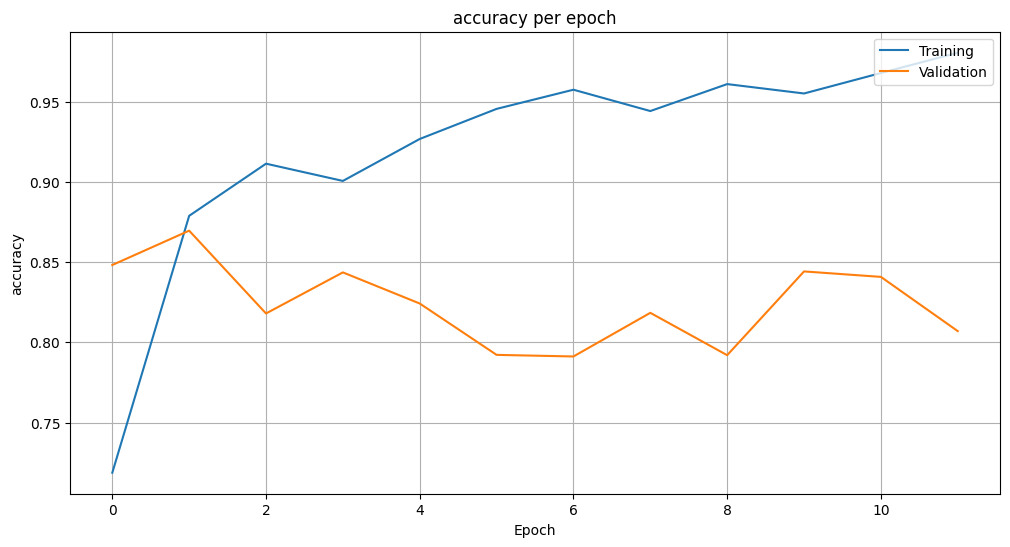

In [76]:
plt.figure(figsize=(12, 6))
plt.plot(history_GRU_GL.history['accuracy'])
plt.plot(history_GRU_GL.history['val_accuracy'])
plt.title('accuracy per epoch')
plt.ylabel('accuracy')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper right')
plt.grid()
plt.show()

In [77]:
GRU_GL.evaluate(X_test, y_test)

782/782 ━━━━━━━━━━━━━━━━━━━━ 43s 55ms/step - accuracy: 0.8618 - loss: 0.3440


[0.3395618796348572, 0.8621199727058411]

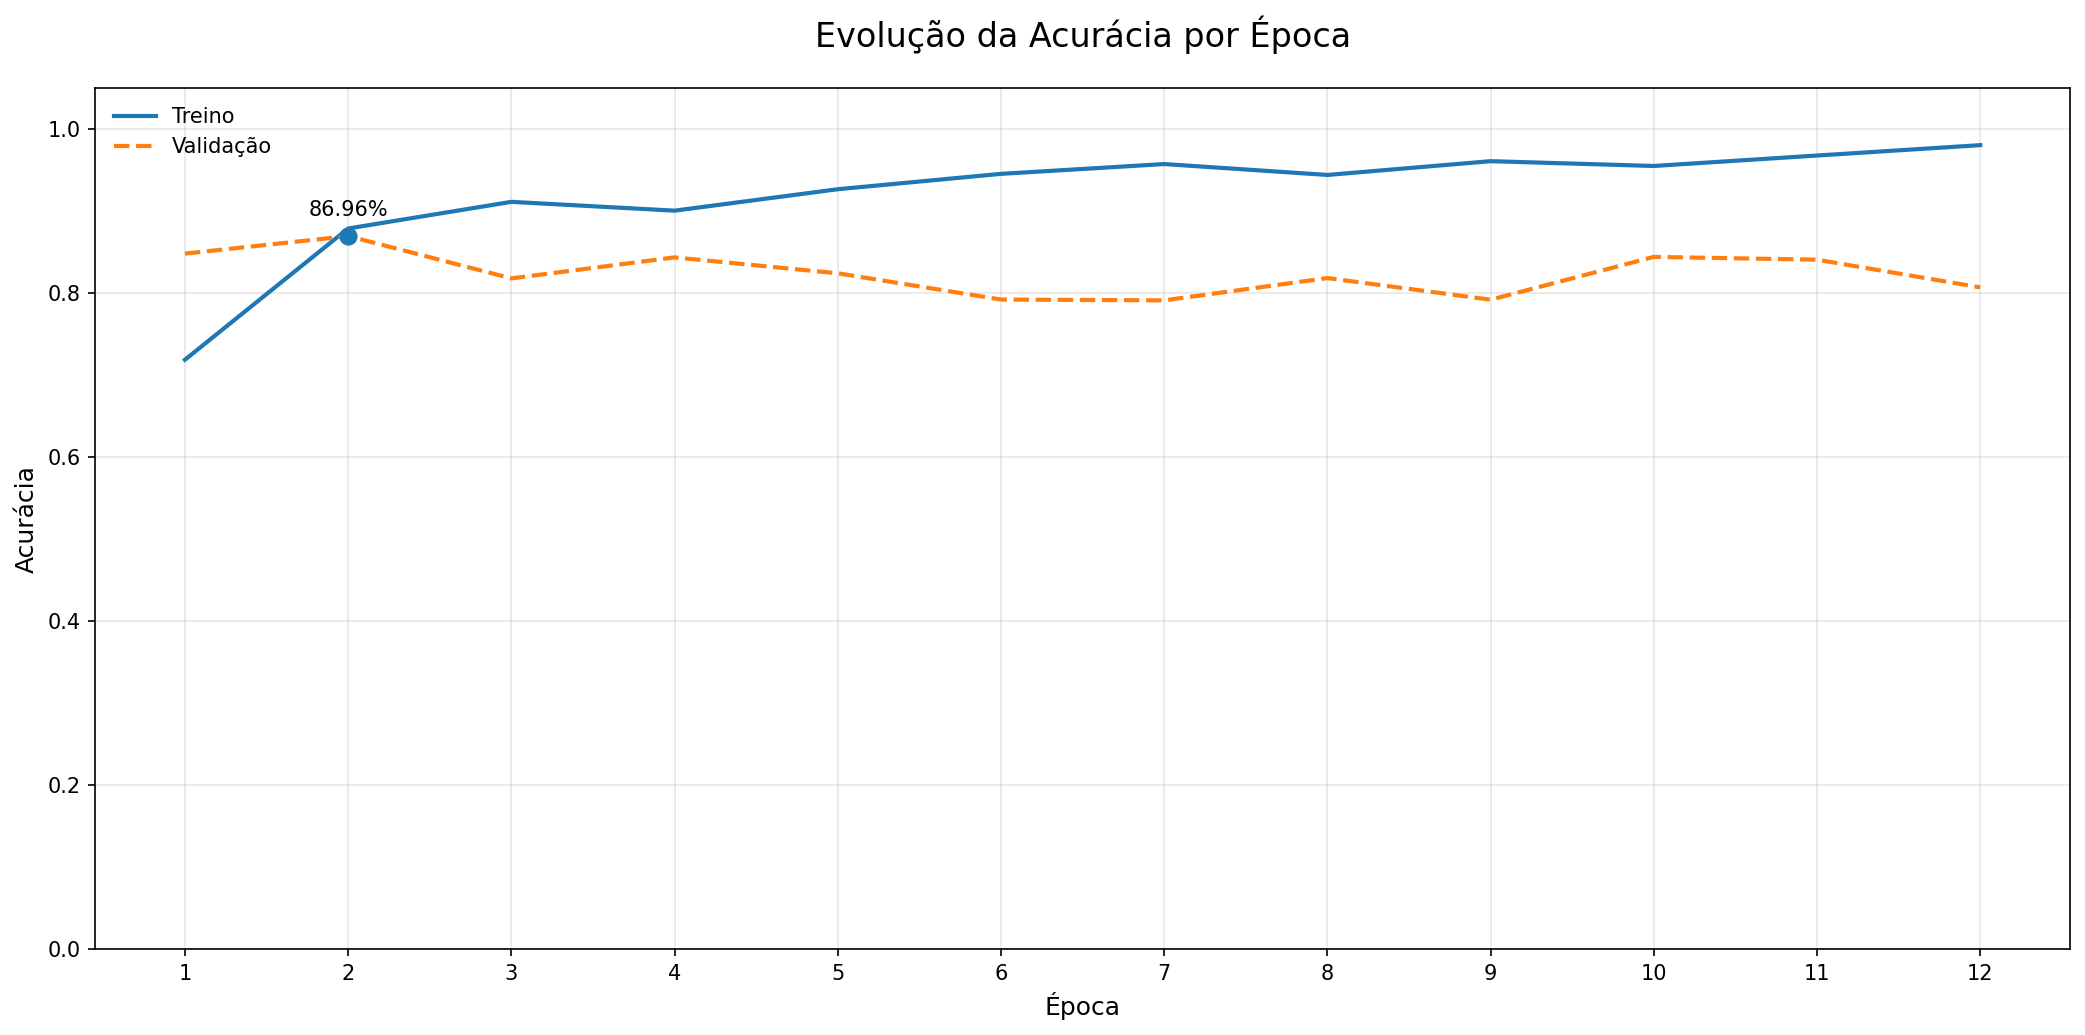

In [78]:
# ─── DADOS ──────────────────────────────────────────────────────────────────────
train_acc = history_GRU_GL.history['accuracy']
val_acc   = history_GRU_GL.history['val_accuracy']
epochs    = range(1, len(train_acc) + 1)

# ─── FIGURA ─────────────────────────────────────────────────────────────────────
plt.figure(figsize=(14, 7), dpi=150)

# Curva de treino
plt.plot(epochs, train_acc,
         label='Treino',
         linewidth=2)

# Curva de validação
plt.plot(epochs, val_acc,
         label='Validação',
         linewidth=2,
         linestyle='--')

# ─── REALCES ÚTEIS ──────────────────────────────────────────────────────────────
# Aponta a melhor época na validação
best_ep   = max(range(len(val_acc)), key=val_acc.__getitem__)
best_val  = val_acc[best_ep]
plt.scatter(best_ep + 1, best_val, s=60, zorder=5)
plt.text(best_ep + 1, best_val + 0.02,
         f'{best_val:.2%}',
         ha='center', va='bottom', fontsize=10)

# ─── ESTILO GERAL ───────────────────────────────────────────────────────────────
plt.title('Evolução da Acurácia por Época', fontsize=16, pad=20)
plt.xlabel('Época', fontsize=12)
plt.ylabel('Acurácia', fontsize=12)
plt.xticks(epochs)              # mostra todas as épocas no eixo-x
plt.ylim(0, 1.05)               # garante visibilidade até 100 %
plt.grid(alpha=0.3)             # grid suave
plt.legend(frameon=False)       # sem moldura no legend
plt.tight_layout()              # encaixa tudo

plt.show()


## LeCun

In [79]:
tf.keras.backend.clear_session()
tf.random.set_seed(42)

In [80]:
GRU_LE= Sequential()
GRU_LE.add(Embedding(max_features, 128, input_length=max_length, input_shape=X_train.shape[1:]))
GRU_LE.add(GRU(64, return_sequences=True,activation="tanh", kernel_initializer=initializer_3))
GRU_LE.add(GRU(64, return_sequences=False,activation="tanh", kernel_initializer=initializer_3))
GRU_LE.add(Dense(1, activation='sigmoid'))

GRU_LE.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 500, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 500, 64)        │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 64)             │        24,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,342,273 (5.12 MB)

 Trainable params: 1,342,273 (5.12 MB)

 Non-trainable params: 0 (0.00 B)

In [81]:
early_stopping= EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
Optimizer= Adam(learning_rate=0.001)

GRU_LE.compile(loss='binary_crossentropy', 
               optimizer=Optimizer, 
               metrics=['accuracy'])

In [82]:
history_GRU_LE= GRU_LE.fit(X_train, y_train, 
                           epochs=500, 
                           batch_size=256, 
                           validation_split=0.2, 
                           callbacks=[early_stopping], 
                           verbose=1)

Epoch 1/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 151s 2s/step - accuracy: 0.6260 - loss: 0.6156 - val_accuracy: 0.8576 - val_loss: 0.3365
Epoch 2/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 144s 2s/step - accuracy: 0.8802 - loss: 0.2863 - val_accuracy: 0.8454 - val_loss: 0.3556
Epoch 3/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 149s 2s/step - accuracy: 0.9022 - loss: 0.2468 - val_accuracy: 0.8498 - val_loss: 0.3557
Epoch 4/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 152s 2s/step - accuracy: 0.9184 - loss: 0.2054 - val_accuracy: 0.8452 - val_loss: 0.4092
Epoch 5/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 152s 2s/step - accuracy: 0.9235 - loss: 0.2004 - val_accuracy: 0.8434 - val_loss: 0.3876
Epoch 6/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 154s 2s/step - accuracy: 0.9397 - loss: 0.1595 - val_accuracy: 0.8264 - val_loss: 0.4188
Epoch 7/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 150s 2s/step - accuracy: 0.9422 - loss: 0.1469 - val_accuracy: 0.8518 - val_loss: 0.4424
Epoch 8/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 153s 2s/step - accuracy: 0.9661 - loss: 0.0890 - val_accuracy: 0.

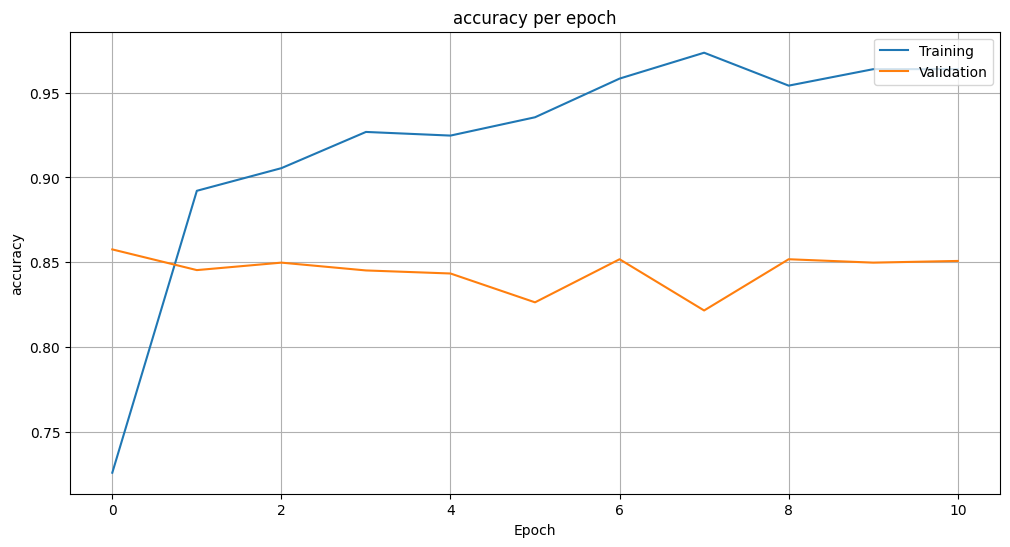

In [83]:
plt.figure(figsize=(12, 6))
plt.plot(history_GRU_LE.history['accuracy'])
plt.plot(history_GRU_LE.history['val_accuracy'])
plt.title('accuracy per epoch')
plt.ylabel('accuracy')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper right')
plt.grid()
plt.show()

In [84]:
GRU_LE.evaluate(X_test, y_test)

782/782 ━━━━━━━━━━━━━━━━━━━━ 50s 64ms/step - accuracy: 0.8508 - loss: 0.3426


[0.33862942457199097, 0.8528800010681152]

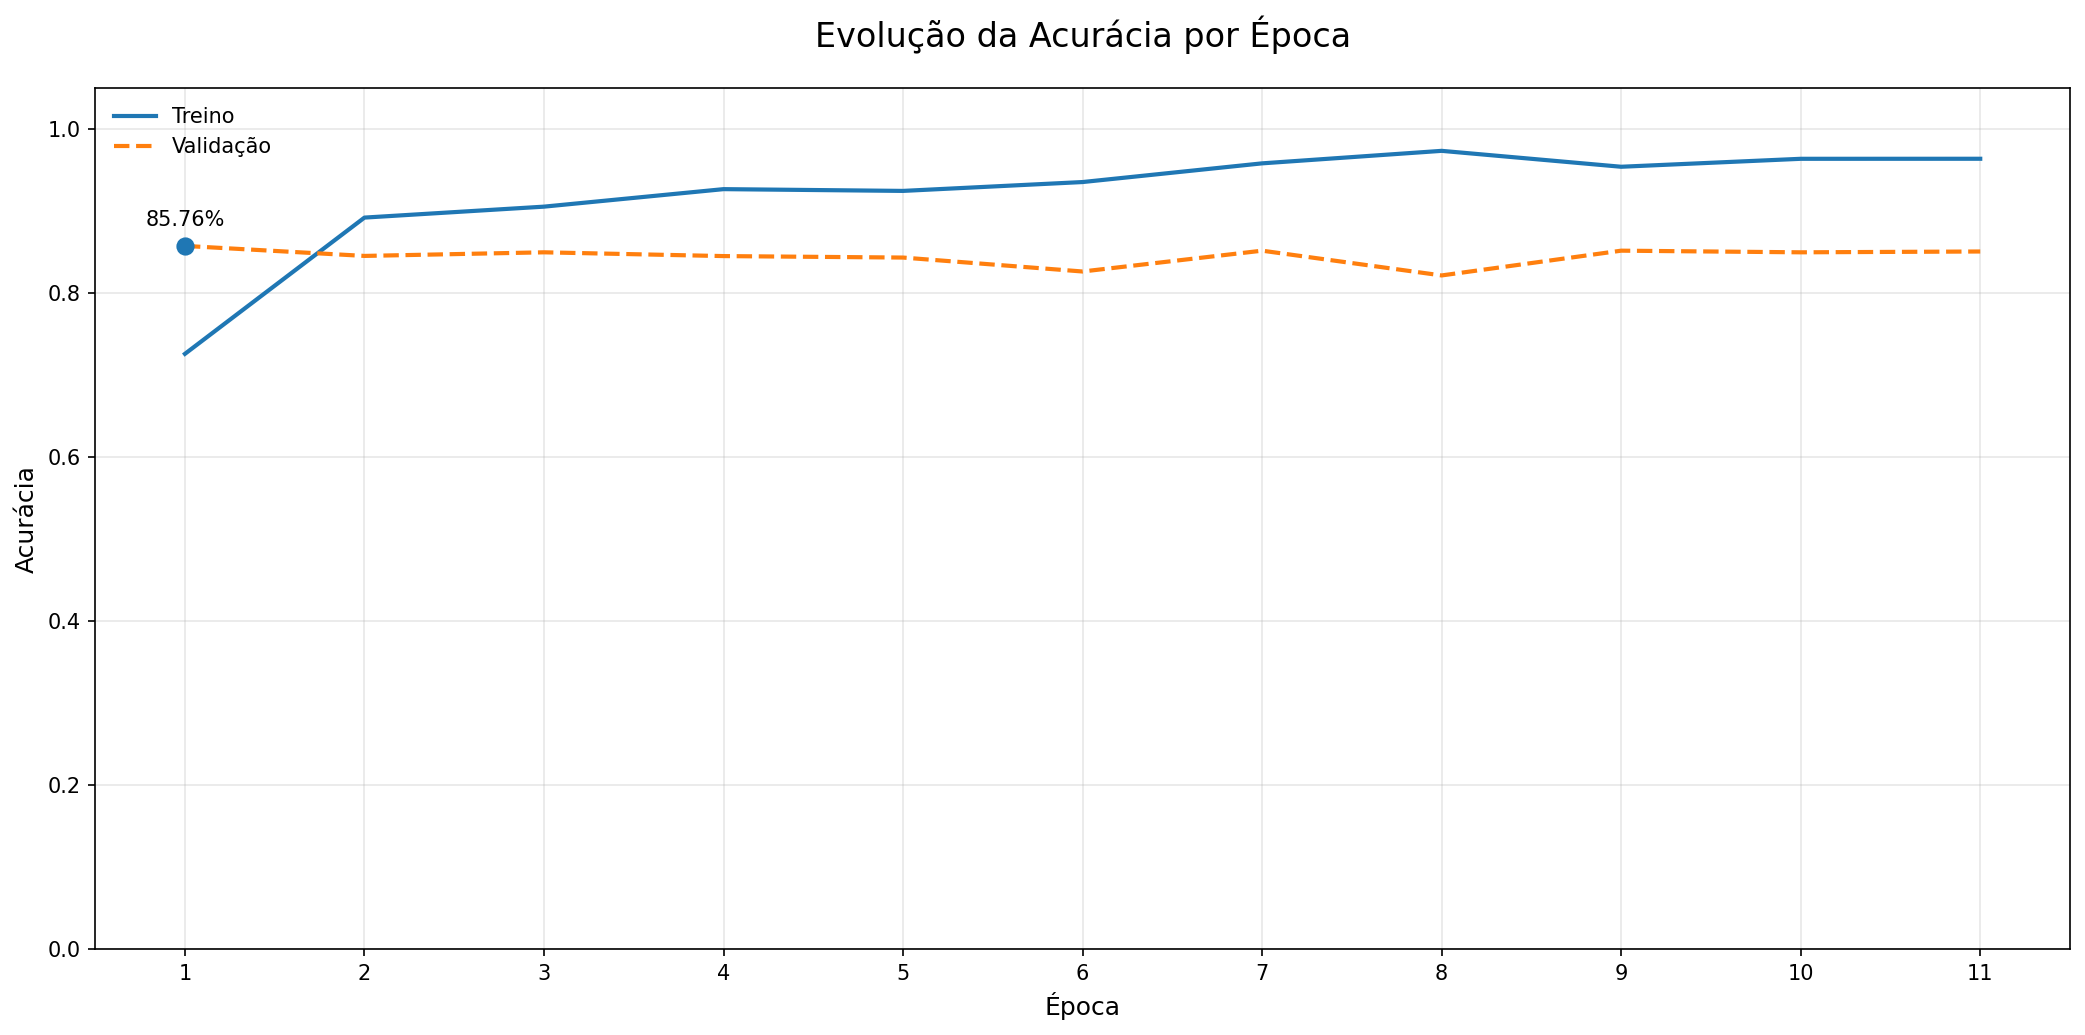

In [85]:
# ─── DADOS ──────────────────────────────────────────────────────────────────────
train_acc = history_GRU_LE.history['accuracy']
val_acc   = history_GRU_LE.history['val_accuracy']
epochs    = range(1, len(train_acc) + 1)

# ─── FIGURA ─────────────────────────────────────────────────────────────────────
plt.figure(figsize=(14, 7), dpi=150)

# Curva de treino
plt.plot(epochs, train_acc,
         label='Treino',
         linewidth=2)

# Curva de validação
plt.plot(epochs, val_acc,
         label='Validação',
         linewidth=2,
         linestyle='--')

# ─── REALCES ÚTEIS ──────────────────────────────────────────────────────────────
# Aponta a melhor época na validação
best_ep   = max(range(len(val_acc)), key=val_acc.__getitem__)
best_val  = val_acc[best_ep]
plt.scatter(best_ep + 1, best_val, s=60, zorder=5)
plt.text(best_ep + 1, best_val + 0.02,
         f'{best_val:.2%}',
         ha='center', va='bottom', fontsize=10)

# ─── ESTILO GERAL ───────────────────────────────────────────────────────────────
plt.title('Evolução da Acurácia por Época', fontsize=16, pad=20)
plt.xlabel('Época', fontsize=12)
plt.ylabel('Acurácia', fontsize=12)
plt.xticks(epochs)              # mostra todas as épocas no eixo-x
plt.ylim(0, 1.05)               # garante visibilidade até 100 %
plt.grid(alpha=0.3)             # grid suave
plt.legend(frameon=False)       # sem moldura no legend
plt.tight_layout()              # encaixa tudo

plt.show()
